# 1. Project Introduction

## 1.1 Problem Definition

This project aims to build and train Classification Models to predict **Client Credit Risk**. The ultimate goal is to categorize each credit card or loan applicant into one of two classes:

1.  **Good Client (Target = 0):** A client with a stable or acceptable repayment history.
2.  **Bad Client (Target = 1):** A client whose credit history shows a history of default (past due for 60 days or more) at any point during the observation period.

This problem is an **Imbalanced Binary Classification** task.

## 1.2 Problem Importance

Risk assessment models are the cornerstone of the financial services industry. Accurate credit risk prediction helps financial institutions achieve critical objectives:

* **Loss Minimization:** Reducing the rate of bad debt incurred by the institution due to issuing credit to high-risk clients.
* **Profitability Improvement:** Identifying low-risk clients to offer them better terms and increase the volume of safe lending.
* **Regulatory Compliance:** Providing transparent and objective reasons for credit application rejection or acceptance.

## 1.3 Machine Learning Contribution

Historically, banks relied on traditional Logistic Regression models for scoring. However, modern Machine Learning algorithms (such as Random Forest and Boosting methods) offer significantly higher predictive power by:

* **Handling Complexity:** Effectively dealing with the complex, non-linear relationships between client features and their risk profile.
* **Accuracy Enhancement:** Delivering superior predictive accuracy, minimizing classification errors, and meeting the project's demanding goal of **achieving an accuracy greater than 90%** on validation and test sets.

In [1]:
!pip install --upgrade scikit-learn imbalanced-learn
! pip install -q xgboost 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 13.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.8.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.0 which

In [2]:
import warnings
warnings.filterwarnings('ignore')

# 2 Files Understanding and Merging 

## 2.1  We are combining two distinct Files

## Dataset Description

This project relies on two related datasets that together describe the personal characteristics of clients and their historical credit behavior. Each dataset serves a distinct and complementary role in the credit risk classification process.



### 1. Application Record Dataset (`application_record.csv`)

The `application_record.csv` file contains **client-level application data** that describes the personal, demographic, and socioeconomic characteristics of individuals at the time of data collection. This dataset represents a **static snapshot** of each client’s profile and does not include any time-dependent information.

Each row in this dataset corresponds to **one unique client**, identified by a client ID. The features capture long-term attributes that typically remain stable over time and are commonly used by financial institutions during the credit application assessment stage.

The dataset includes information related to:
- **Demographics**, such as gender, age, and family composition
- **Financial background**, including total annual income and income source
- **Education and employment-related attributes**
- **Lifestyle and asset ownership**, such as car and property ownership
- **Housing conditions and living arrangements**
- **Communication availability indicators**, including phone and email flags
- **Occupational information**

Overall, this dataset serves as the **primary source of input features (X)** for the machine learning models, as it describes who the client is and their financial and social background before any credit behavior is observed.


### 2. Credit Record Dataset (`credit_record.csv`)

The `credit_record.csv` file contains **historical credit behavior data** recorded on a monthly basis for each client. Unlike the application dataset, this file is **time-dependent** and tracks how a client’s credit status changes over time.

Each client can appear multiple times in this dataset, with each row representing a **monthly credit status record**. The timeline is expressed using a relative month index, where the current month is represented as zero and previous months are represented by negative values.

The dataset includes:
- A client identifier used to link records to the application dataset
- Monthly timestamps indicating the relative timing of each record
- Credit status codes that describe payment behavior, including on-time payments, varying levels of delinquency, and non-active credit periods

This dataset does not directly contain model input features. Instead, it is primarily used to **derive the target variable (credit risk label)** by analyzing historical repayment behavior over time. It provides the ground truth needed to distinguish between reliable and high-risk clients.

In the context of this project, `credit_record.csv` plays a critical role in defining the **classification outcome**, while `application_record.csv` supplies the explanatory variables used for prediction.


In [3]:
import pandas as pd

data_df = pd.read_csv("/kaggle/input/credit-card-approval-prediction/application_record.csv")
record_df = pd.read_csv("/kaggle/input/credit-card-approval-prediction/credit_record.csv")

In [4]:
print(f"Data_DF Shape :  {data_df.shape}")
print(f"record_DF Shape :  {record_df.shape}")

Data_DF Shape :  (438557, 18)
record_DF Shape :  (1048575, 3)


In [5]:
print(f"Data_Features :{data_df.columns.to_list()} \n")
print(f"Record_Features :{record_df.columns.to_list()}")

Data_Features :['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'] 

Record_Features :['ID', 'MONTHS_BALANCE', 'STATUS']


In [6]:
data_df.sample(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
338304,6391932,F,N,Y,0,270000.0,Working,Secondary / secondary special,Separated,House / apartment,-22976,-6165,1,0,0,0,Cleaning staff,1.0
103816,5436088,F,N,Y,0,76500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-23392,365243,1,0,1,0,NaN,2.0
255764,6064480,F,N,Y,0,117000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-17792,-3301,1,0,0,0,Accountants,2.0
338118,6391545,F,N,N,0,103500.0,Working,Secondary / secondary special,Married,House / apartment,-10959,-3759,1,1,0,0,Core staff,2.0
293384,6152111,F,N,N,0,157500.0,State servant,Secondary / secondary special,Single / not married,House / apartment,-19035,-4334,1,0,0,0,Secretaries,1.0


In [7]:
record_df.sample(5)

,ID,MONTHS_BALANCE,STATUS
443498,5053574,-19,0
19605,5002606,-9,C
730722,5100011,-14,C
855554,5118561,-2,C
496460,5060819,-14,C


In [8]:
bad_status = ['2', '3', '4', '5']
record_df['Target'] = record_df['STATUS'].apply(lambda x: 1 if x in bad_status else 0)

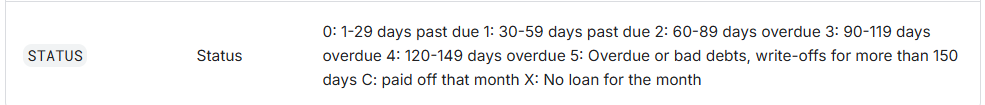
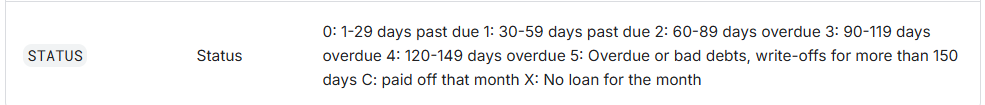

In [9]:
record_df.head(10)

,ID,MONTHS_BALANCE,STATUS,Target
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0
5,5001712,-1,C,0
6,5001712,-2,C,0
7,5001712,-3,C,0
8,5001712,-4,C,0
9,5001712,-5,C,0


In [10]:
record_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
 3   Target          1048575 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 32.0+ MB


In [11]:
target_df = record_df.groupby('ID')['Target'].max().reset_index()

print(target_df.head())
print(f"Taret Count: {len(target_df)}")

        ID  Target
0  5001711       0
1  5001712       0
2  5001713       0
3  5001714       0
4  5001715       0
Taret Count: 45985


In [12]:
final_df = pd.merge(data_df, target_df, on='ID', how='inner')

In [13]:
duplicates_count = final_df.duplicated(subset=['ID']).sum()
print(f"Duplicates: {duplicates_count}")

if duplicates_count > 0:
    print("Removing duplicates...")
    final_df.drop_duplicates(subset=['ID'], keep='first', inplace=True) 
    print("Duplicates removed successfully")
else:
    print("No duplicates found. Data is clean")

Duplicates: 0
No duplicates found. Data is clean


In [14]:
final_df = final_df.drop('ID', axis=1)

In [15]:
print(final_df.shape)
print(final_df.columns)

(36457, 18)
Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'Target'],
      dtype='object')


In [16]:
final_df.rename(columns={'CODE_GENDER':'Gender','FLAG_OWN_CAR':'Car','FLAG_OWN_REALTY':'Reality',
                         'CNT_CHILDREN':'ChldNo','AMT_INCOME_TOTAL':'inc',
                         'NAME_EDUCATION_TYPE':'edutp','NAME_FAMILY_STATUS':'famtp',
                        'NAME_HOUSING_TYPE':'houtp','FLAG_EMAIL':'email',
                         'NAME_INCOME_TYPE':'inctp','FLAG_WORK_PHONE':'wkphone',
                         'FLAG_PHONE':'phone','CNT_FAM_MEMBERS':'famsize',
                        'OCCUPATION_TYPE':'occyp'
                        },inplace=True)

In [17]:
print(final_df.columns)

Index(['Gender', 'Car', 'Reality', 'ChldNo', 'inc', 'inctp', 'edutp', 'famtp',
       'houtp', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'wkphone',
       'phone', 'email', 'occyp', 'famsize', 'Target'],
      dtype='object')


# 2.2 Initial Data Observations & Target Engineering Rationale

Based on the preliminary data loading and the target variable engineering process, the following critical observations were made:

### 1. Target Variable Construction Rationale

* **Absence of Direct Target:** The datasets (`application_record` and `credit_record`) do not contain a pre-defined target variable (Good/Bad client).
* **Engineering Criterion:** The Target variable was engineered using the `STATUS` column in the `credit_record` (the helper criteria). A client is categorized as 'Bad' (Target=1) if their payment status reached any of the severe delinquency levels ($\in \{2, 3, 4, 5\}$) at any point in the history.
    * *Delinquency Status $\ge 60$ days past due:* 2, 3, 4, 5 (Overdue or Bad Debts).
    * *Acceptable Status:* 0, 1, C, X.

### 2. Dataset Merging and Size Discrepancy

* **Initial Sizes:** The `data_df` (Application Records) has **438,557** rows, while `record_df` (Monthly Credit History) has **1,048,575** rows. This difference is expected as a single client can have multiple monthly records.
* **AFter Grouping Record Based On the ID and Taking Only The Max Credit Status it Become equal to 45985**
* **Post-Merge Size:** After performing an **Inner Join** based on the common key `ID`, the resulting `final_df` size dropped significantly to **36,457** rows with 18 input features and the engineered 'Target' variable.

### 3. Conclusion on Dataset Size

* **Justification for Size Reduction:** The large drop in rows is necessary and normal because:
    * The `Inner Join` ensures that only clients who have a corresponding **Credit History (`credit_record` entry)** are retained.
    * The excluded $\approx 402,000$ clients likely represent applicants who were rejected or whose credit history was not recorded in the observed period, and thus lack the necessary data to determine their **risk status** (Target).
* **Project Compliance:** The resulting dataset size of **36,457** records is robust and well above the minimum requirement of 10,000 records.

# 3. Exploratory Data Analysis (EDA) & Feature Understanding

This step involves a brief but clear analysis of the dataset to understand the features and the target variable, identifying data quality issues, and preparing an effective preprocessing strategy.


## i. Dataset Overview 

In [18]:
final_df.sample(10)

,Gender,Car,Reality,ChldNo,inc,inctp,edutp,famtp,houtp,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,wkphone,phone,email,occyp,famsize,Target
3794,F,N,Y,0,202500.0,Working,Secondary / secondary special,Widow,House / apartment,-17782,-9975,1,0,0,0,Core staff,1.0,0
6818,F,N,N,0,112500.0,Working,Higher education,Married,With parents,-10650,-3702,1,1,1,0,Core staff,2.0,0
2064,M,N,Y,1,270000.0,State servant,Secondary / secondary special,Married,House / apartment,-17110,-370,1,0,0,0,Laborers,3.0,0
35283,F,N,Y,1,225000.0,Commercial associate,Higher education,Separated,House / apartment,-15226,-1020,1,0,1,0,Sales staff,2.0,0
31329,F,N,Y,0,153000.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,-22029,365243,1,0,0,1,NaN,1.0,0
22127,F,N,Y,0,157500.0,Working,Secondary / secondary special,Married,House / apartment,-17301,-4734,1,0,1,0,Medicine staff,2.0,0
10062,M,Y,Y,1,247500.0,Working,Higher education,Married,Municipal apartment,-15606,-160,1,0,1,0,Sales staff,3.0,0
14828,F,N,N,0,153000.0,Pensioner,Secondary / secondary special,Widow,House / apartment,-16354,365243,1,0,0,0,NaN,1.0,0
28542,M,Y,Y,1,225000.0,State servant,Secondary / secondary special,Married,House / apartment,-11695,-3929,1,1,0,0,Laborers,3.0,0
26883,M,N,Y,2,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11462,-4606,1,0,0,0,Laborers,4.0,0


In [19]:
print(f"Data set shape : {final_df.shape}")

Data set shape : (36457, 18)


In [20]:
features = final_df.columns.drop('Target').to_list()
print(f"Final Data_Features  :{features} \n")
print("Target Is Target")

Final Data_Features  :['Gender', 'Car', 'Reality', 'ChldNo', 'inc', 'inctp', 'edutp', 'famtp', 'houtp', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'wkphone', 'phone', 'email', 'occyp', 'famsize'] 

Target Is Target


In [21]:
print(final_df.describe(include='all').T)

                 count unique                            top   freq  \
Gender           36457      2                              F  24430   
Car              36457      2                              N  22614   
Reality          36457      2                              Y  24506   
ChldNo         36457.0    NaN                            NaN    NaN   
inc            36457.0    NaN                            NaN    NaN   
inctp            36457      5                        Working  18819   
edutp            36457      5  Secondary / secondary special  24777   
famtp            36457      5                        Married  25048   
houtp            36457      6              House / apartment  32548   
DAYS_BIRTH     36457.0    NaN                            NaN    NaN   
DAYS_EMPLOYED  36457.0    NaN                            NaN    NaN   
FLAG_MOBIL     36457.0    NaN                            NaN    NaN   
wkphone        36457.0    NaN                            NaN    NaN   
phone 

In [22]:
final_df.describe(include=['number'])

,ChldNo,inc,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,wkphone,phone,email,famsize,Target
count,36457.000000,3.645700e+04,36457.000000,36457.000000,36457.0,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000
mean,0.430315,1.866857e+05,-15975.173382,59262.935568,1.0,0.225526,0.294813,0.089722,2.198453,0.016897
std,0.742367,1.017892e+05,4200.549944,137651.334859,0.0,0.417934,0.455965,0.285787,0.911686,0.128886
min,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,1.215000e+05,-19438.000000,-3153.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,0.000000,1.575000e+05,-15563.000000,-1552.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,1.000000,2.250000e+05,-12462.000000,-408.000000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,19.000000,1.575000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000,1.000000


In [23]:
import numpy as np 
cols_to_drop = []
cols_to_check = final_df.columns
for col_name in cols_to_check:    
    if final_df[col_name].nunique() <= 1:
        cols_to_drop.append(col_name)
        
for col in cols_to_drop:
    print (f"{col} Value Counts : \n" , final_df[col].value_counts(),"\n")

FLAG_MOBIL Value Counts : 
 FLAG_MOBIL
1    36457
Name: count, dtype: int64 



In [24]:
final_df.drop(columns = cols_to_drop, inplace = True)

In [25]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gender         36457 non-null  object 
 1   Car            36457 non-null  object 
 2   Reality        36457 non-null  object 
 3   ChldNo         36457 non-null  int64  
 4   inc            36457 non-null  float64
 5   inctp          36457 non-null  object 
 6   edutp          36457 non-null  object 
 7   famtp          36457 non-null  object 
 8   houtp          36457 non-null  object 
 9   DAYS_BIRTH     36457 non-null  int64  
 10  DAYS_EMPLOYED  36457 non-null  int64  
 11  wkphone        36457 non-null  int64  
 12  phone          36457 non-null  int64  
 13  email          36457 non-null  int64  
 14  occyp          25134 non-null  object 
 15  famsize        36457 non-null  float64
 16  Target         36457 non-null  int64  
dtypes: float64(2), int64(7), object(8)
memory usage: 4

## The dataset consists of profile-based features describing the applicant's personal, financial, and employment status. Below is a brief description of each variable:

* **Gender:** Indicates the gender of the applicant (Male/Female).
* **Car / Reality:** Binary flags indicating whether the client owns a car or real estate property.
* **inc (Annual Income):** The total annual income of the client.
* **inctp (Income Type):** The category of the income source (e.g., Working, Commercial associate, Pensioner).
* **edutp (Education Level):** The highest level of education achieved by the client (Ordered hierarchy).
* **famtp (Marital Status):** The client's current marital status.
* **houtp (Housing Type):** Describes the client's living situation (e.g., House/Apartment, Rented, With parents).
* **occyp (Occupation):** The specific job title or profession of the client.
* **famsize / ChldNo:** The size of the family and the count of children, respectively.
* **Contact Flags (wkphone, phone, email):** Indicators of the availability of contact methods.
* **AGE_YEARS:** The applicant's age in years (Derived from `DAYS_BIRTH`).
* **EMPLOYMENT_YEARS:** The duration of current employment in years (Derived from `DAYS_EMPLOYED`).
* **Target:** The classification label where **0** represents a 'Good Client' (Approved) and **1** represents a 'Bad Client' (Rejected/Risk).

---

## ii. Feature Type Identification

### Critrie of Selection Based on df 

This criteria outlines the classification of features based on their technical characteristics (dtype) and the number of unique values.

1) ***Numerical:***
* **Initial Definition:** Any column (COL) with `dtype` equal to `float64` or `int64`.
* **Refinement 1 (ID Check):** It is recommended to further verify that the column has a **high number of unique values** (i.e., not a unique identifier like `ID`).
* **Refinement 2 (Binary Check - **CRITICAL**):** We must perform an **EXTRA CHECK** to exclude any column where the number of unique values is **2 or less** (e.g., 0/1 or Yes/No). Columns meeting this condition are not Numerical, but **Binary Categorical** features and should be treated with Label Encoding.

> **Final List (Post-Check):** Only columns that pass both refinements (high number of unique values AND more than 2 unique values) will be kept as Numerical features, such as `AMT_INCOME_TOTAL`, `AGE_YEARS`, and `EMPLOYMENT_YEARS`.


2) ***Binary Categorical:***
    * Any COL (regardless of original `dtype`: `Object`, `category`, `int`, or `float`) that has **Only 2 unique Values** (`nunique() == 2`).

3) ***Ordinal Categorical:***
    * Any COL with `dtype` **`Object`** (or `category`) that has **Ordinal Values** (values that possess a logical, inherent order, e.g., 'Low', 'Medium', 'High').
    * *Note:* This classification requires **manual human assessment** and must exclude columns already identified as Binary.

4) ***Nominal Categorical:***
    * Any COL with `dtype` **`Object`** (or `category`) that has **Not On The prev Classes** (i.e., the remaining categorical variables).
    * *Meaning:* Columns whose unique value count is greater than 2 and which possess no inherent logical ordering.

In [26]:
final_df.dtypes.value_counts()

object     8
int64      7
float64    2
Name: count, dtype: int64

In [27]:
numerical_df = final_df.select_dtypes(exclude=['object'])

numerical_df.head()

,ChldNo,inc,DAYS_BIRTH,DAYS_EMPLOYED,wkphone,phone,email,famsize,Target
0,0,427500.0,-12005,-4542,1,0,0,2.0,0
1,0,427500.0,-12005,-4542,1,0,0,2.0,0
2,0,112500.0,-21474,-1134,0,0,0,2.0,0
3,0,270000.0,-19110,-3051,0,1,1,1.0,0
4,0,270000.0,-19110,-3051,0,1,1,1.0,0


In [28]:
cols_with_high_unique_values = []
for col in numerical_df.columns.to_list():
    if col in final_df.columns:
        unique_count = final_df[col].nunique() 
        total_rows = len(final_df)              
        unique_ratio_percentage = (unique_count / total_rows) * 100
        if unique_ratio_percentage > 5 :
            val = {'name': col, 'unique_count': unique_count, 'ratio_percentage': f"{unique_ratio_percentage:.2f}%"} 
            cols_with_high_unique_values.append(val)

print(cols_with_high_unique_values)

[{'name': 'DAYS_BIRTH', 'unique_count': 7183, 'ratio_percentage': '19.70%'}, {'name': 'DAYS_EMPLOYED', 'unique_count': 3640, 'ratio_percentage': '9.98%'}]


In [29]:
cols_names_with_high_unique_values = [item['name'] for item in cols_with_high_unique_values]
final_df[cols_names_with_high_unique_values].describe()

,DAYS_BIRTH,DAYS_EMPLOYED
count,36457.000000,36457.000000
mean,-15975.173382,59262.935568
std,4200.549944,137651.334859
min,-25152.000000,-15713.000000
25%,-19438.000000,-3153.000000
50%,-15563.000000,-1552.000000
75%,-12462.000000,-408.000000
max,-7489.000000,365243.000000


***Continuous Time Feature Handling***

In [30]:
final_df['AGE_YEARS'] = (final_df['DAYS_BIRTH'] / -365.25).round(0)

In [31]:
final_df['IS_UNEMPLOYED'] = (final_df['DAYS_EMPLOYED'] > 0).astype(int)

In [32]:
final_df.loc[final_df['DAYS_EMPLOYED'] > 0, 'DAYS_EMPLOYED'] = 0

In [33]:
final_df['EMPLOYMENT_YEARS'] = (final_df['DAYS_EMPLOYED'] / -365.25).round(0)

In [34]:
final_df[['AGE_YEARS','EMPLOYMENT_YEARS','IS_UNEMPLOYED']].nunique()

AGE_YEARS           49
EMPLOYMENT_YEARS    44
IS_UNEMPLOYED        2
dtype: int64

In [35]:
final_df[['AGE_YEARS','EMPLOYMENT_YEARS','IS_UNEMPLOYED']].head()

,AGE_YEARS,EMPLOYMENT_YEARS,IS_UNEMPLOYED
0,33.0,12.0,0
1,33.0,12.0,0
2,59.0,3.0,0
3,52.0,8.0,0
4,52.0,8.0,0


In [36]:
final_df[['AGE_YEARS','EMPLOYMENT_YEARS','IS_UNEMPLOYED']].describe()

,AGE_YEARS,EMPLOYMENT_YEARS,IS_UNEMPLOYED
count,36457.000000,36457.000000,36457.00000
mean,43.746057,6.036783,0.16828
std,11.513873,6.488058,0.37412
min,21.000000,-0.000000,0.00000
25%,34.000000,1.000000,0.00000
50%,43.000000,4.000000,0.00000
75%,53.000000,9.000000,0.00000
max,69.000000,43.000000,1.00000


In [37]:
final_df.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1, inplace=True)

In [38]:
numerical_df = final_df.select_dtypes(exclude=['object'])

In [39]:
binary_num = []
for col_name in numerical_df.columns:
    if numerical_df[col_name].nunique() == 2:
        binary_num.append(col_name)

print(f"Binary_numric_features are : {binary_num}")

Binary_numric_features are : ['wkphone', 'phone', 'email', 'Target', 'IS_UNEMPLOYED']


In [40]:
numerical_df.drop(columns=binary_num, inplace=True)

print(f"numric_features are : {numerical_df.columns.to_list()}" )

numric_features are : ['ChldNo', 'inc', 'famsize', 'AGE_YEARS', 'EMPLOYMENT_YEARS']


In [41]:
bin_cat=[]
categorical_df = final_df.select_dtypes(include=['object'])
for col_name in categorical_df.columns:
    if categorical_df[col_name].nunique() == 2:
        bin_cat.append(col_name)

print(f"Binary_categoric_features are : {bin_cat}")

Binary_categoric_features are : ['Gender', 'Car', 'Reality']


In [42]:
other_categorical = categorical_df.drop(columns=bin_cat, inplace=False)
other_categorical.sample(10)

,inctp,edutp,famtp,houtp,occyp
29144,Pensioner,Secondary / secondary special,Married,House / apartment,NaN
1776,State servant,Secondary / secondary special,Married,With parents,Drivers
3528,Working,Secondary / secondary special,Married,House / apartment,Drivers
28687,Working,Secondary / secondary special,Married,House / apartment,Sales staff
32080,Commercial associate,Secondary / secondary special,Married,House / apartment,Laborers
17170,Working,Secondary / secondary special,Married,House / apartment,NaN
19126,Commercial associate,Secondary / secondary special,Separated,House / apartment,Core staff
25442,Working,Higher education,Married,House / apartment,Accountants
30691,Working,Secondary / secondary special,Married,House / apartment,Low-skill Laborers
27758,Working,Secondary / secondary special,Civil marriage,House / apartment,Drivers


In [43]:
ordinal_cat =["edutp"]

In [44]:
nominal_cat = other_categorical.drop(columns=ordinal_cat, inplace=False) 
nominal_cat.head()

,inctp,famtp,houtp,occyp
0,Working,Civil marriage,Rented apartment,NaN
1,Working,Civil marriage,Rented apartment,NaN
2,Working,Married,House / apartment,Security staff
3,Commercial associate,Single / not married,House / apartment,Sales staff
4,Commercial associate,Single / not married,House / apartment,Sales staff


In [45]:
numric_cols = numerical_df.columns.to_list()
print(f"numric_features are : \n {numric_cols} \n" )
final_df[numric_cols].head()

numric_features are : 
 ['ChldNo', 'inc', 'famsize', 'AGE_YEARS', 'EMPLOYMENT_YEARS'] 



,ChldNo,inc,famsize,AGE_YEARS,EMPLOYMENT_YEARS
0,0,427500.0,2.0,33.0,12.0
1,0,427500.0,2.0,33.0,12.0
2,0,112500.0,2.0,59.0,3.0
3,0,270000.0,1.0,52.0,8.0
4,0,270000.0,1.0,52.0,8.0


In [46]:
print(f"Binary_features That Needc Label Encoding are : \n {bin_cat} \n")
final_df[bin_cat].head()

Binary_features That Needc Label Encoding are : 
 ['Gender', 'Car', 'Reality'] 



,Gender,Car,Reality
0,M,Y,Y
1,M,Y,Y
2,M,Y,Y
3,F,N,Y
4,F,N,Y


In [47]:
print(f"Binary_Ready_Encoded_features are : \n {binary_num} \n")
final_df[binary_num].head()

Binary_Ready_Encoded_features are : 
 ['wkphone', 'phone', 'email', 'Target', 'IS_UNEMPLOYED'] 



,wkphone,phone,email,Target,IS_UNEMPLOYED
0,1,0,0,0,0
1,1,0,0,0,0
2,0,0,0,0,0
3,0,1,1,0,0
4,0,1,1,0,0


In [48]:
print(f"ordinal_cat_features are : \n{ordinal_cat} \n")
final_df[ordinal_cat].head()

ordinal_cat_features are : 
['edutp'] 



,edutp
0,Higher education
1,Higher education
2,Secondary / secondary special
3,Secondary / secondary special
4,Secondary / secondary special


In [49]:
nominal_cols = nominal_cat.columns.to_list()
print(f"nominal_cat_features are : \n{nominal_cols} \n " )
final_df[nominal_cols].head()

nominal_cat_features are : 
['inctp', 'famtp', 'houtp', 'occyp'] 
 


,inctp,famtp,houtp,occyp
0,Working,Civil marriage,Rented apartment,NaN
1,Working,Civil marriage,Rented apartment,NaN
2,Working,Married,House / apartment,Security staff
3,Commercial associate,Single / not married,House / apartment,Sales staff
4,Commercial associate,Single / not married,House / apartment,Sales staff


## iii. Missing Values Analysis 

In [50]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            36457 non-null  object 
 1   Car               36457 non-null  object 
 2   Reality           36457 non-null  object 
 3   ChldNo            36457 non-null  int64  
 4   inc               36457 non-null  float64
 5   inctp             36457 non-null  object 
 6   edutp             36457 non-null  object 
 7   famtp             36457 non-null  object 
 8   houtp             36457 non-null  object 
 9   wkphone           36457 non-null  int64  
 10  phone             36457 non-null  int64  
 11  email             36457 non-null  int64  
 12  occyp             25134 non-null  object 
 13  famsize           36457 non-null  float64
 14  Target            36457 non-null  int64  
 15  AGE_YEARS         36457 non-null  float64
 16  IS_UNEMPLOYED     36457 non-null  int64 

In [51]:
final_df.isnull().sum()

Gender                  0
Car                     0
Reality                 0
ChldNo                  0
inc                     0
inctp                   0
edutp                   0
famtp                   0
houtp                   0
wkphone                 0
phone                   0
email                   0
occyp               11323
famsize                 0
Target                  0
AGE_YEARS               0
IS_UNEMPLOYED           0
EMPLOYMENT_YEARS        0
dtype: int64

In [52]:
print("Null Values In occ_Type : " , final_df["occyp"].isnull().sum())
perc = (final_df["occyp"].isnull().sum() / len(final_df["occyp"])*100)
print(f"Null Values Percentage In occ_Type : {perc.round(0)}%")

Null Values In occ_Type :  11323
Null Values Percentage In occ_Type : 31.0%


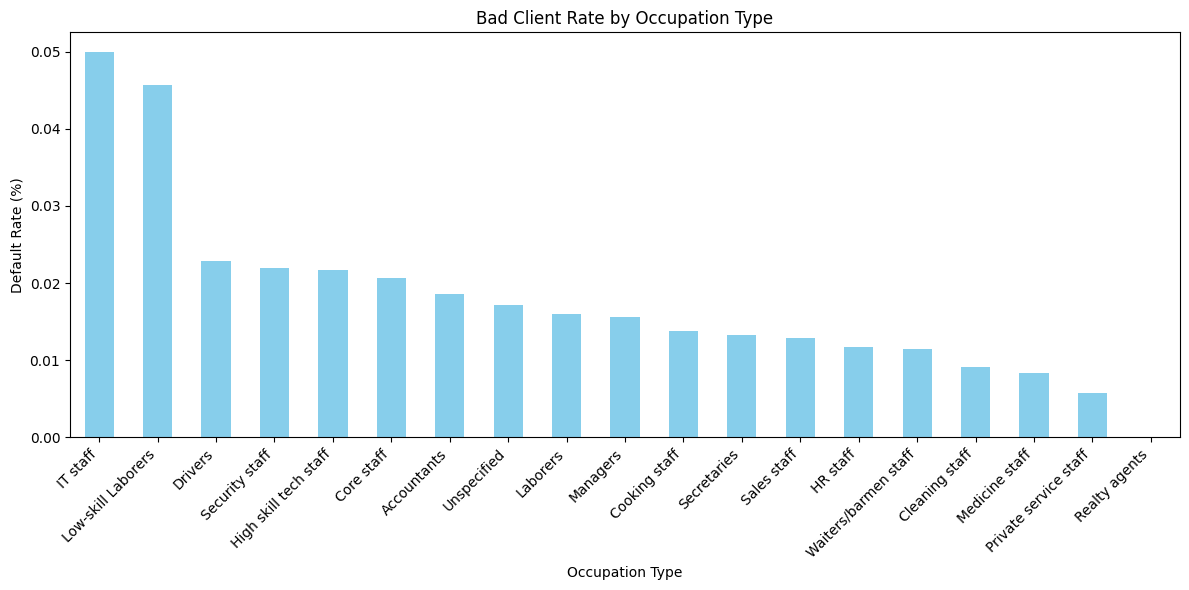

occyp
IT staff                 0.050000
Low-skill Laborers       0.045714
Drivers                  0.022919
Security staff           0.021959
High skill tech staff    0.021692
Core staff               0.020607
Accountants              0.018533
Unspecified              0.017133
Laborers                 0.015939
Managers                 0.015604
Cooking staff            0.013740
Secretaries              0.013245
Sales staff              0.012912
HR staff                 0.011765
Waiters/barmen staff     0.011494
Cleaning staff           0.009074
Medicine staff           0.008285
Private service staff    0.005814
Realty agents            0.000000
Name: Target, dtype: float64


In [53]:
import matplotlib.pyplot as plt

occupation_analysis = final_df.copy()

occupation_analysis['occyp'].fillna('Unspecified', inplace=True)


risk_by_occupation = occupation_analysis.groupby('occyp')['Target'].mean().sort_values(ascending=False)


plt.figure(figsize=(12, 6))
risk_by_occupation.plot(kind='bar', color='skyblue')
plt.title('Bad Client Rate by Occupation Type')
plt.ylabel('Default Rate (%)')
plt.xlabel('Occupation Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(risk_by_occupation)

In [54]:
occupation_stats = occupation_analysis.groupby('occyp')['Target'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)

print(occupation_stats)

                       count      mean
occyp                                 
IT staff                  60  0.050000
Low-skill Laborers       175  0.045714
Drivers                 2138  0.022919
Security staff           592  0.021959
High skill tech staff   1383  0.021692
Core staff              3591  0.020607
Accountants             1241  0.018533
Unspecified            11323  0.017133
Laborers                6211  0.015939
Managers                3012  0.015604
Cooking staff            655  0.013740
Secretaries              151  0.013245
Sales staff             3485  0.012912
HR staff                  85  0.011765
Waiters/barmen staff     174  0.011494
Cleaning staff           551  0.009074
Medicine staff          1207  0.008285
Private service staff    344  0.005814
Realty agents             79  0.000000


## Imputation Strategy for OCCUPATION_TYPE

The primary goal of imputation is to handle missing values (`NaN`) in the `occyp` feature effectively before modeling.

### Imputation Method: Mode Imputation (or Custom Categorical Imputation)

| Method | Feature | Rationale |
| :--- | :--- | :--- |
| **Custom Categorical Imputation** | `occyp` | The missing values (`NaN`) are imputed with the specific category **'Unspecified'**. |

### Rationale for Choosing 'Unspecified'

The decision to impute missing values with the custom category 'Unspecified' (instead of the statistical Mode) is based on the following analytical and domain considerations:

1.  **Analytical Insight from Risk Analysis (Target Relationship):**
    * The provided code and the resulting bar chart demonstrate a strong analytical decision: the missing values, if they were treated as `NaN` and then imputed as a separate category, have been shown to have a distinct default risk.
    * The imputation strategy explicitly sets `occupation_analysis['OCCUPATION_TYPE'].fillna('Unspecified', inplace=True)`.
    * By assigning 'Unspecified' to the missing records, this method treats "missingness" itself as a **meaningful feature** that may influence the target variable (`Target`).

2.  **Model Performance and Information Preservation:**
    * **Avoids Bias:** Unlike simple **Mode Imputation** (which would assign the most frequent occupation, potentially 'Laborers' or 'Working', thus artificially increasing their count), creating a new category preserves the inherent distribution of the existing data.
    * **Captures Unique Risk:** The risk analysis (as shown in the code/plot) confirms that the 'Unspecified' category (which represents the original `NaN` records) has a specific and measurable default rate (0.017133). This risk is likely different from the risk associated with the true Mode. By keeping 'Unspecified' separate, the model can learn the unique risk associated with individuals whose occupation is unknown.

3.  **Nature of the Data:**
    * Since `OCCUPATION_TYPE` is a **Nominal Categorical** feature, using the mean or median is inappropriate. Mode imputation is the standard alternative, but a custom category is preferred when the missing data is not missing at random (MAR).

## iv. Feature Distribution

In [55]:
def analyze_numerical_distribution(df , Has_outliers):
    """Draw Boxplot for Outlier Detection and Histogram for skewness"""
    num_cols = df.shape[1]
    fig, axes = plt.subplots(num_cols, 2, figsize=(15, 5 * num_cols))
    
    if num_cols == 1:
        axes = [axes] 
        
    for i, col in enumerate(df.columns):
        skewness = df[col].skew()
        
        sns.histplot(df[col], kde=True, ax=axes[i][0])
        axes[i][0].set_title(f'Histogram For{col} (Skew: {skewness:.2f})')
        axes[i][0].set_xlabel(col)

        sns.boxplot(y=df[col], ax=axes[i][1])
        axes[i][1].set_title(f'Boxplot for {col}')
        axes[i][1].set_ylabel(col)
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        if outliers_count > 0 :
            out_Percent=(outliers_count/len(df[col]))*100
            Has_outliers.append({"Column Name":col , 'outliers_count' : outliers_count , "out_Percent":f"{int(out_Percent)}%"})
    print(f"The Col Names Which contain Outliers :\n {Has_outliers}\n ")   
    plt.tight_layout()
    plt.show()
    return Has_outliers



In [56]:
import seaborn as sns
import numpy as np

The Col Names Which contain Outliers :
 [{'Column Name': 'ChldNo', 'outliers_count': 508, 'out_Percent': '1%'}, {'Column Name': 'inc', 'outliers_count': 1529, 'out_Percent': '4%'}, {'Column Name': 'famsize', 'outliers_count': 480, 'out_Percent': '1%'}, {'Column Name': 'EMPLOYMENT_YEARS', 'outliers_count': 1323, 'out_Percent': '3%'}]
 


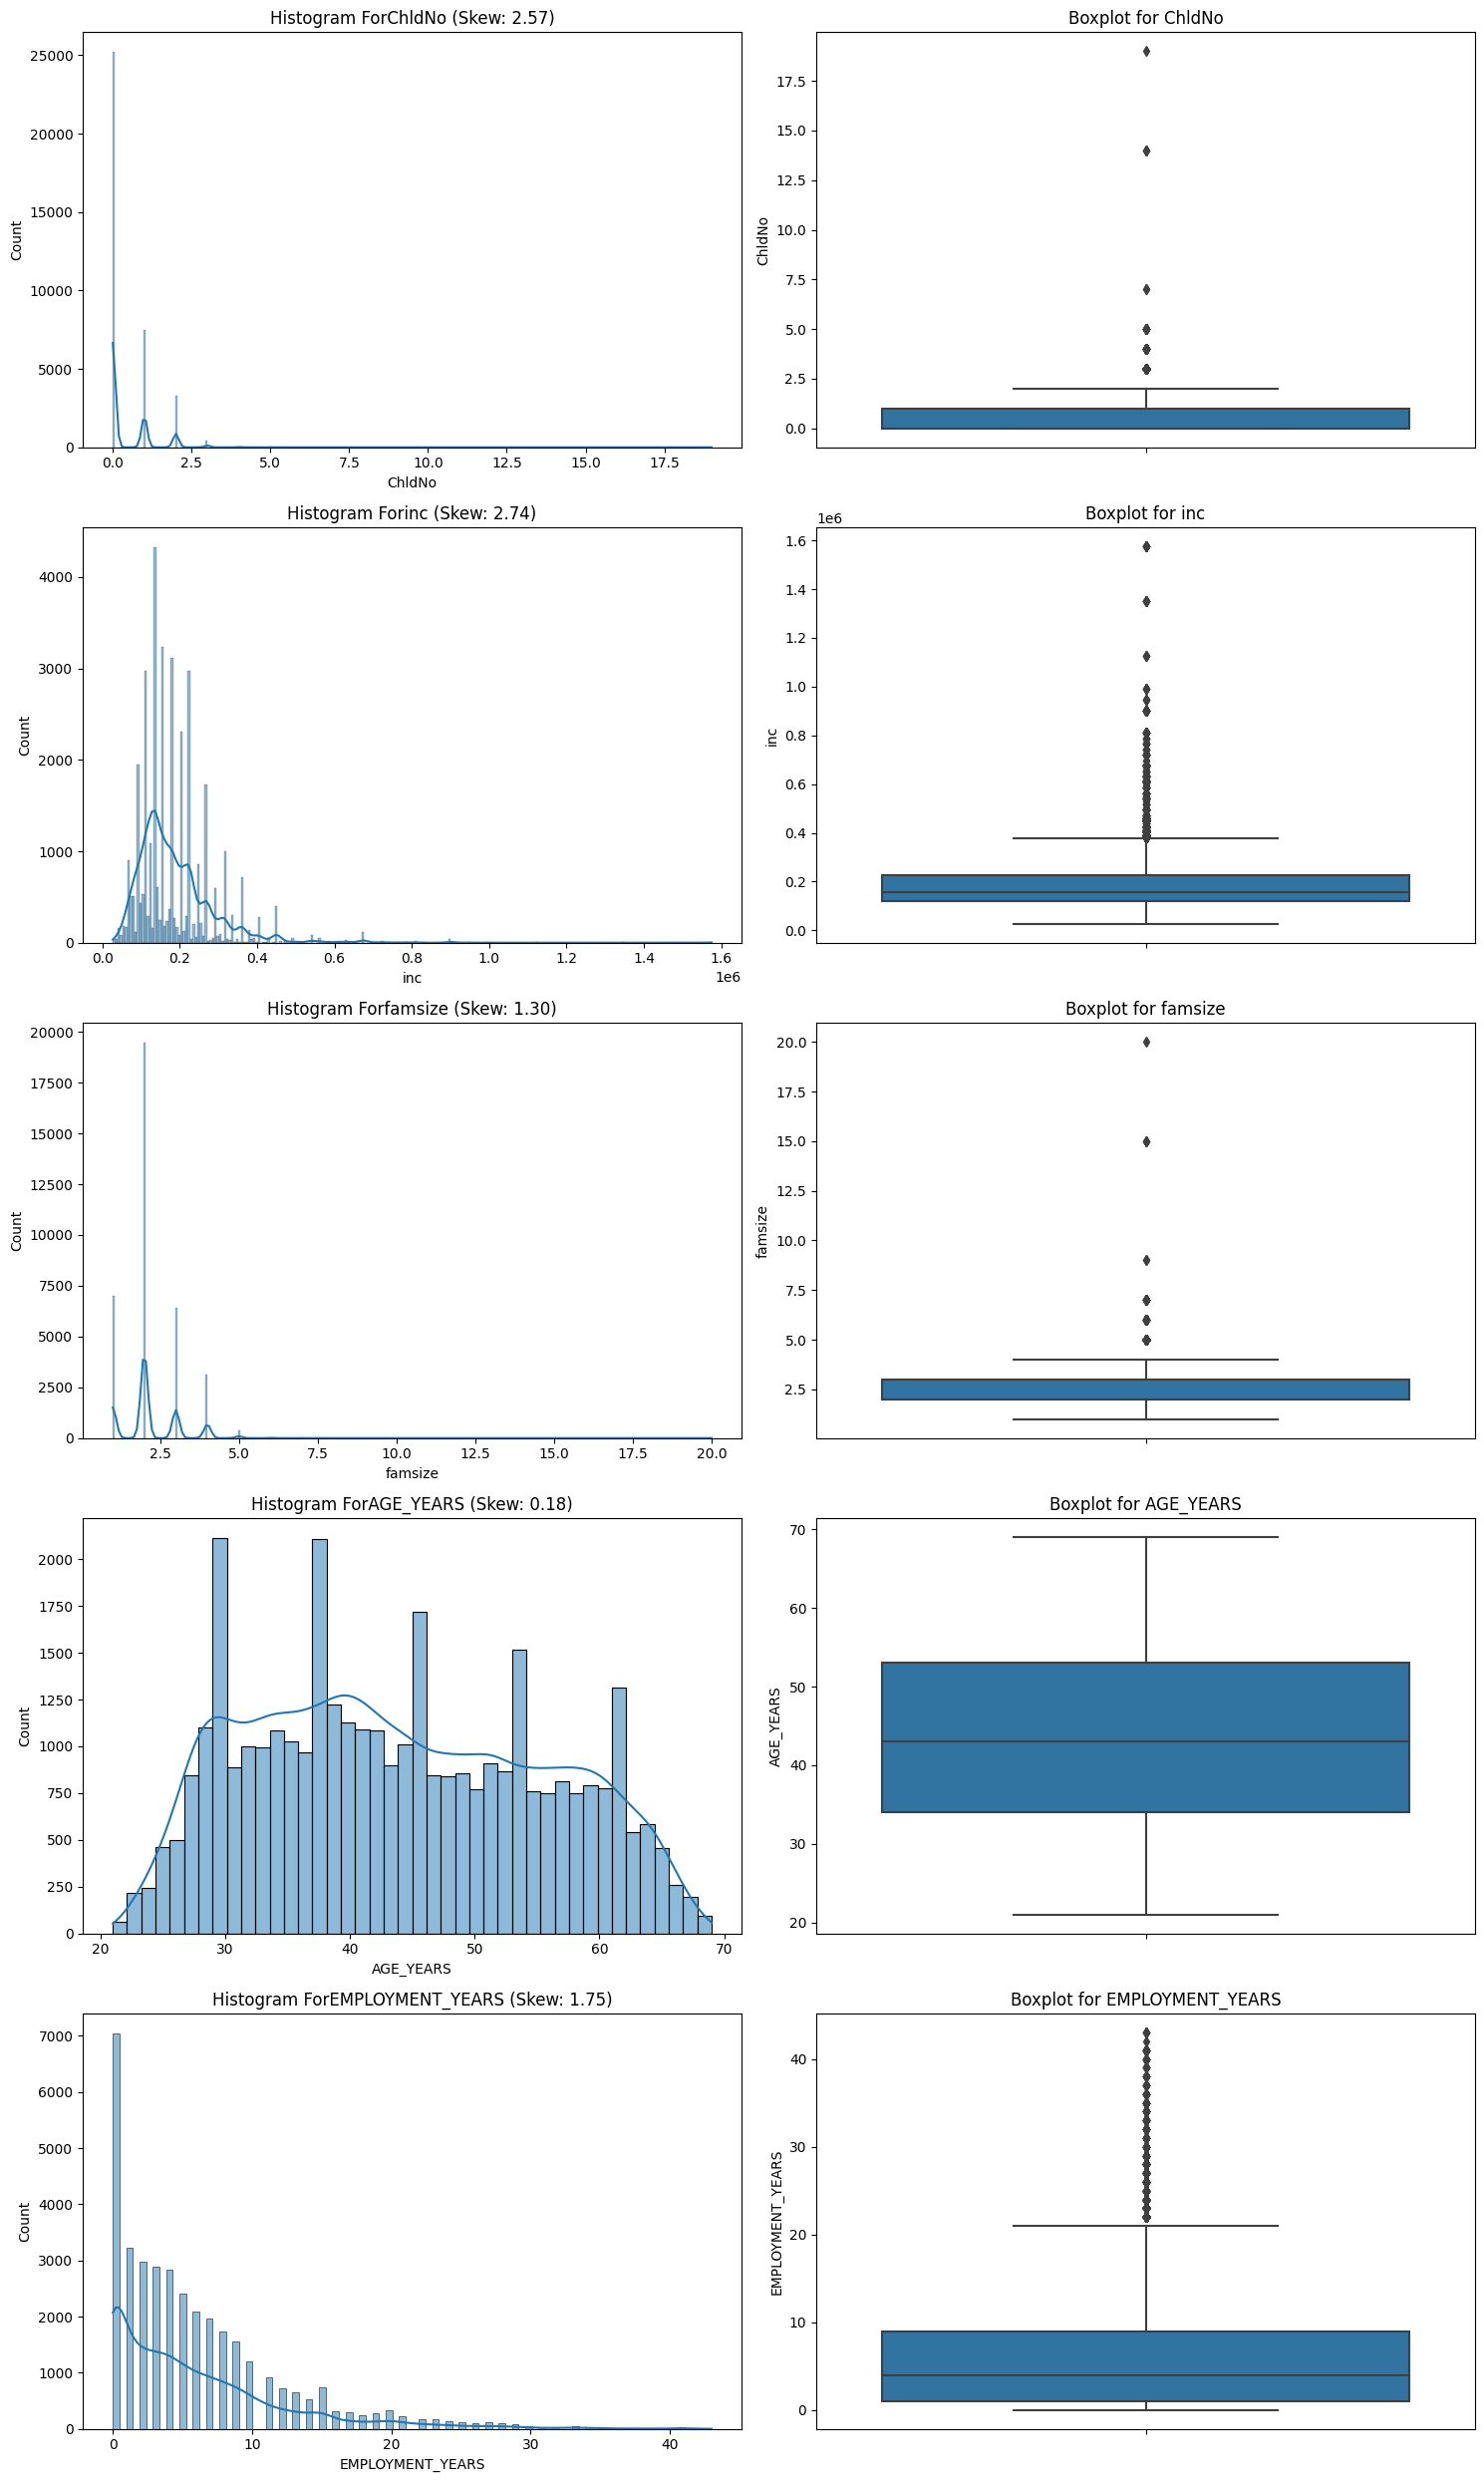

In [57]:
Has_outliers =[]
Has_outliers = analyze_numerical_distribution(numerical_df , Has_outliers)

In [58]:
Has_outliers

[{'Column Name': 'ChldNo', 'outliers_count': 508, 'out_Percent': '1%'},
 {'Column Name': 'inc', 'outliers_count': 1529, 'out_Percent': '4%'},
 {'Column Name': 'famsize', 'outliers_count': 480, 'out_Percent': '1%'},
 {'Column Name': 'EMPLOYMENT_YEARS',
  'outliers_count': 1323,
  'out_Percent': '3%'}]

In [59]:
columns_with_outliers = [item['Column Name'] for item in Has_outliers]
final_df[columns_with_outliers].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,ChldNo,inc,famsize,EMPLOYMENT_YEARS
count,36457.000000,3.645700e+04,36457.000000,36457.000000
mean,0.430315,1.866857e+05,2.198453,6.036783
std,0.742367,1.017892e+05,0.911686,6.488058
min,0.000000,2.700000e+04,1.000000,-0.000000
1%,0.000000,5.400000e+04,1.000000,-0.000000
5%,0.000000,7.650000e+04,1.000000,-0.000000
50%,0.000000,1.575000e+05,2.000000,4.000000
95%,2.000000,3.600000e+05,4.000000,20.000000
99%,3.000000,5.602500e+05,5.000000,29.000000
max,19.000000,1.575000e+06,20.000000,43.000000


In [60]:
final_df[columns_with_outliers].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,ChldNo,inc,famsize,EMPLOYMENT_YEARS
count,36457.000000,3.645700e+04,36457.000000,36457.000000
mean,0.430315,1.866857e+05,2.198453,6.036783
std,0.742367,1.017892e+05,0.911686,6.488058
min,0.000000,2.700000e+04,1.000000,-0.000000
1%,0.000000,5.400000e+04,1.000000,-0.000000
5%,0.000000,7.650000e+04,1.000000,-0.000000
50%,0.000000,1.575000e+05,2.000000,4.000000
95%,2.000000,3.600000e+05,4.000000,20.000000
99%,3.000000,5.602500e+05,5.000000,29.000000
max,19.000000,1.575000e+06,20.000000,43.000000


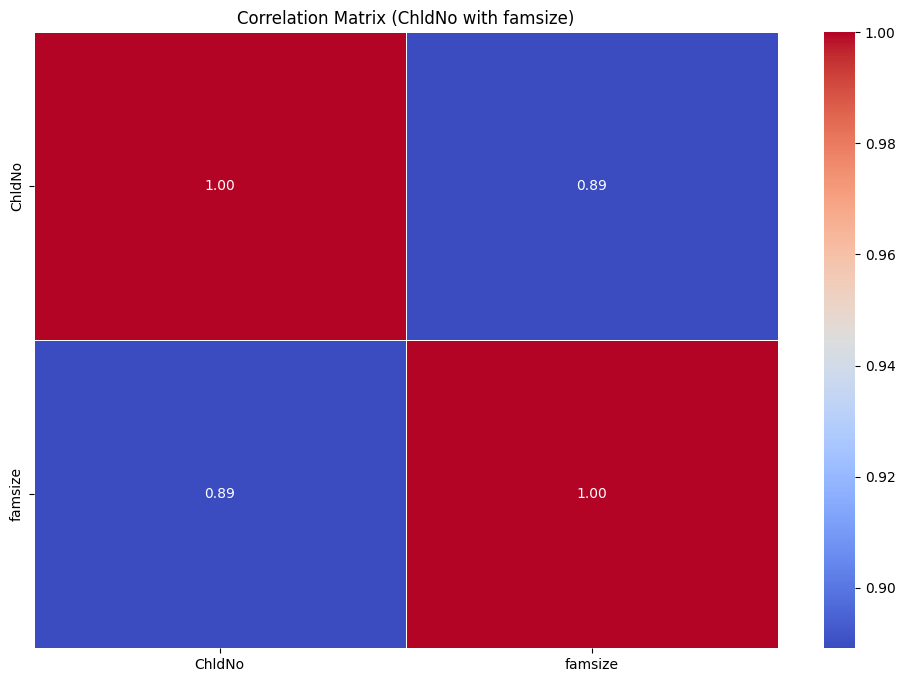

In [61]:
corr = final_df[['ChldNo', 'famsize']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (ChldNo with famsize)')
plt.show()

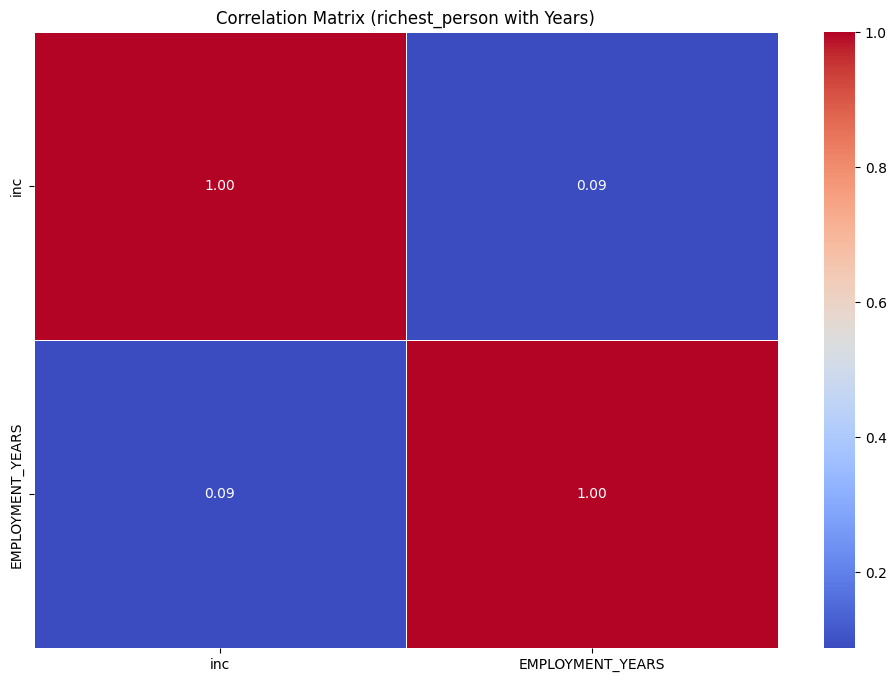

In [62]:
corr = final_df[['inc', 'EMPLOYMENT_YEARS']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (richest_person with Years)')
plt.show()

In [63]:
def analyze_categorical_distribution_correct(df):
    
    num_cols = df.shape[1]
    
    cols_per_row = 2 
    num_rows = (num_cols + cols_per_row - 1) // cols_per_row 
    
    fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(16, 7 * num_rows))
    
    axes = axes.flatten() 

    for i, col in enumerate(df.columns):
        freq = df[col].value_counts()
        
        sns.countplot(y=col, data=df, ax=axes[i], order=freq.index, palette='viridis')
        axes[i].set_title(f'Bar Chart for {col}', fontsize=14)
        axes[i].set_xlabel('Count', fontsize=12)
        axes[i].set_ylabel(col, fontsize=12)
        
    for j in range(num_cols, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()


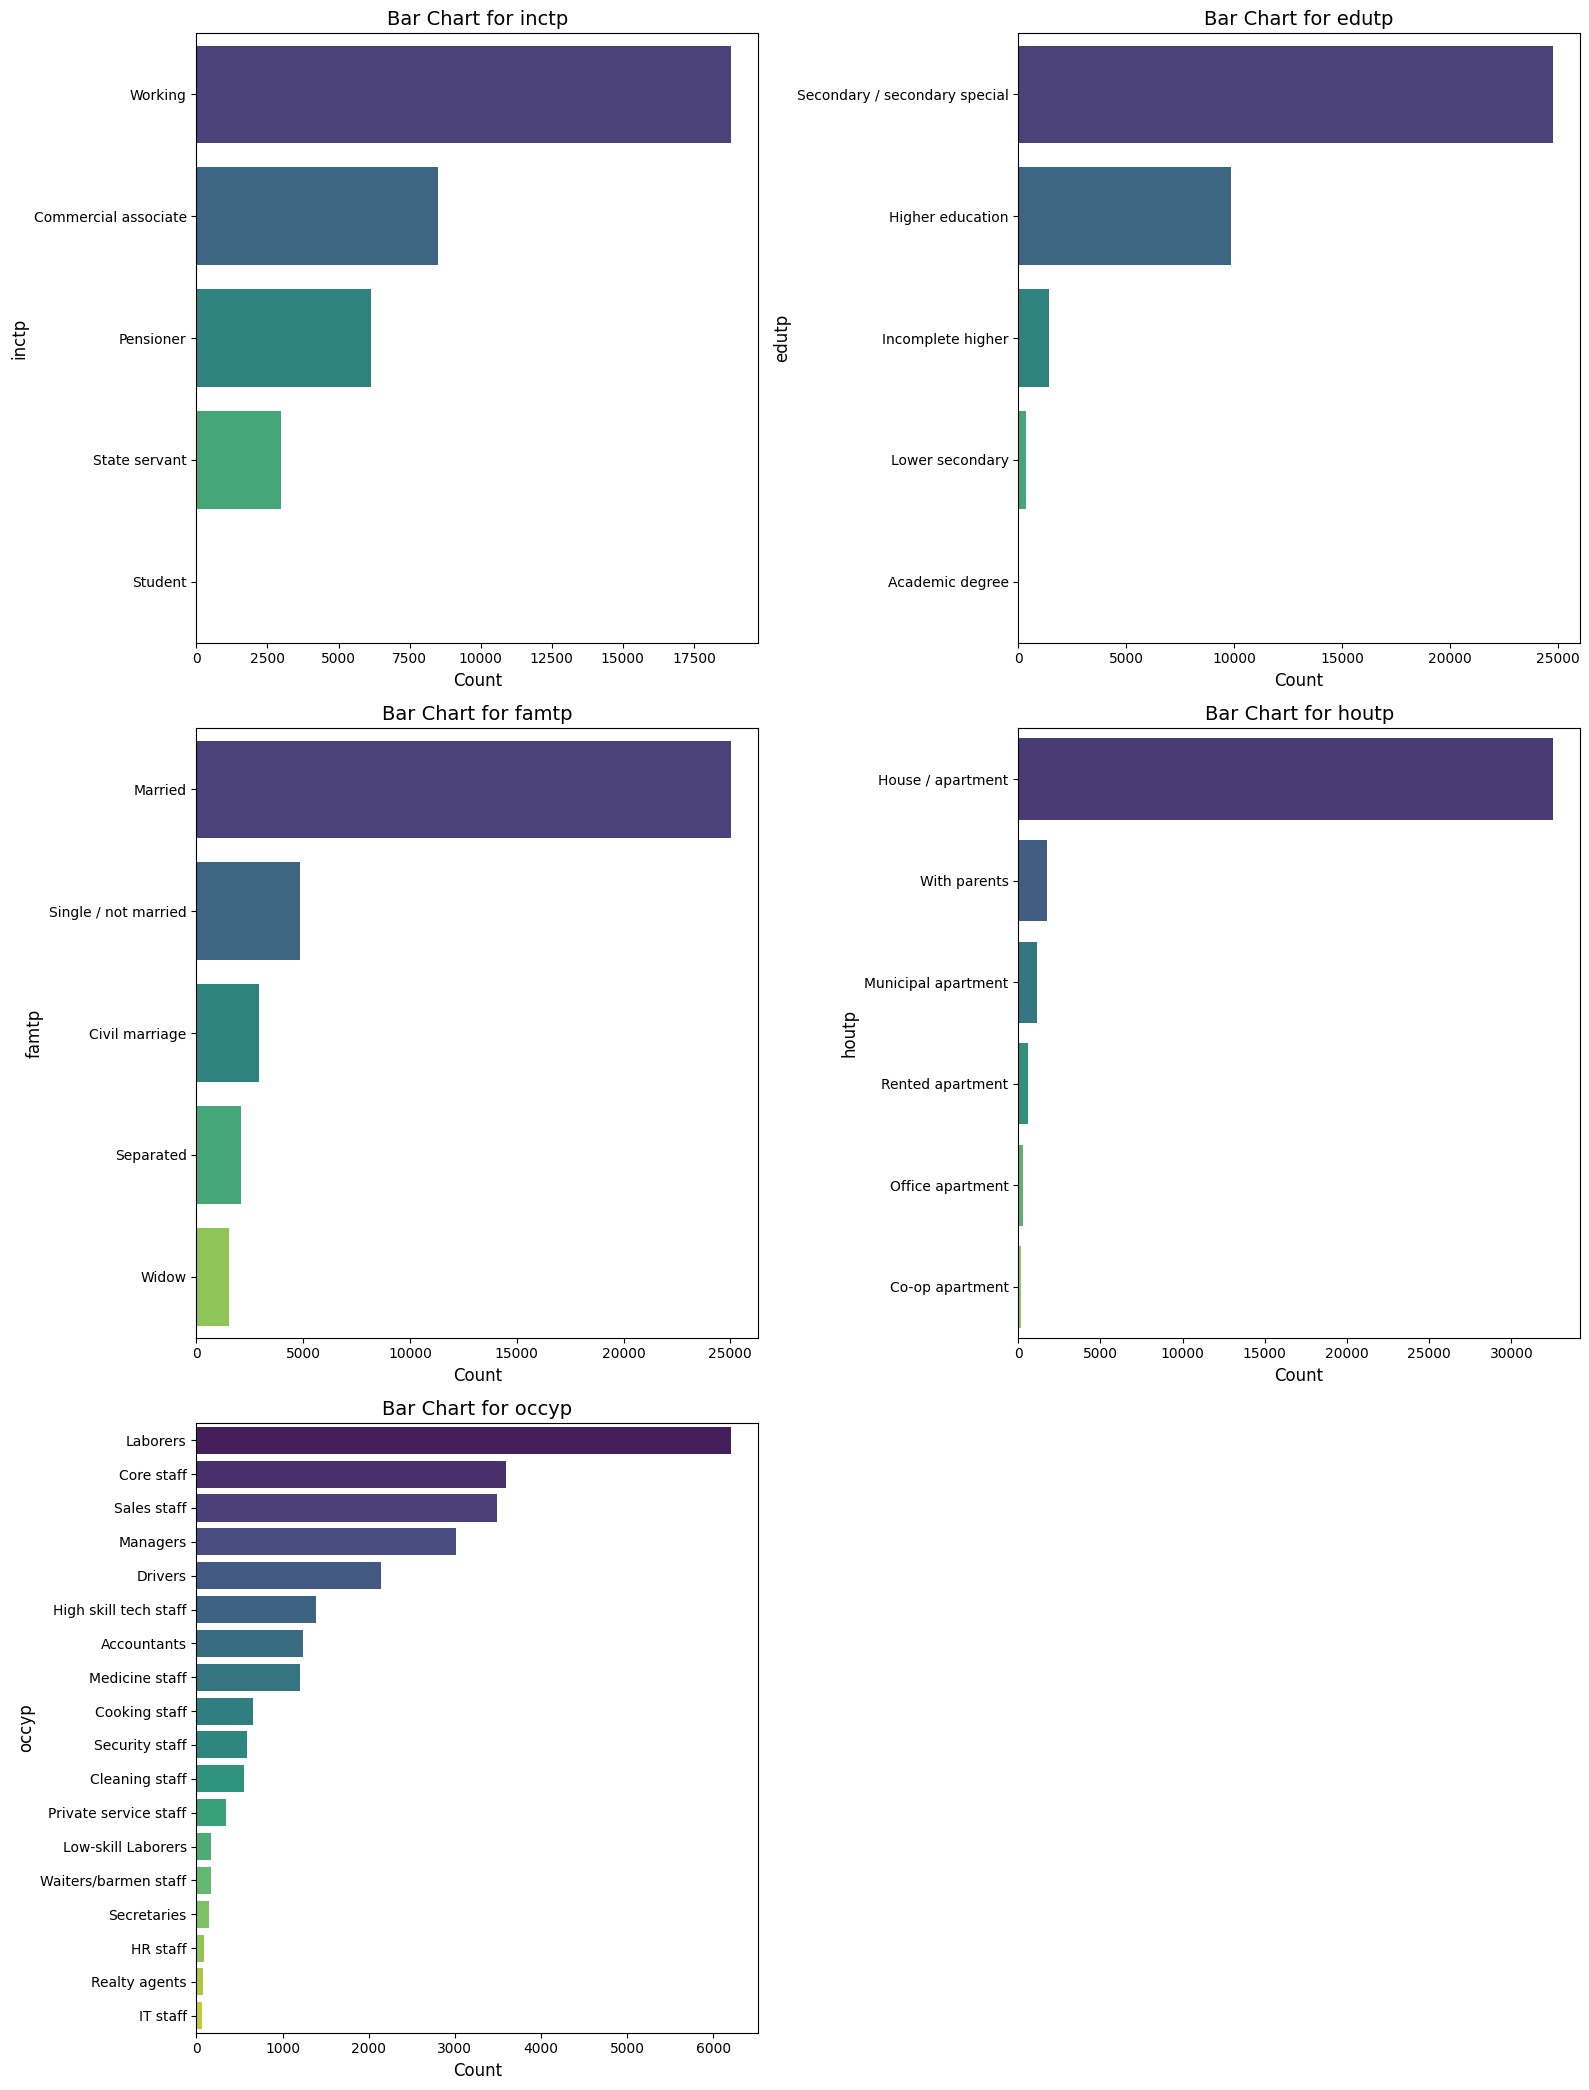

In [64]:
analyze_categorical_distribution_correct(other_categorical)

## v. Feature Relationships 


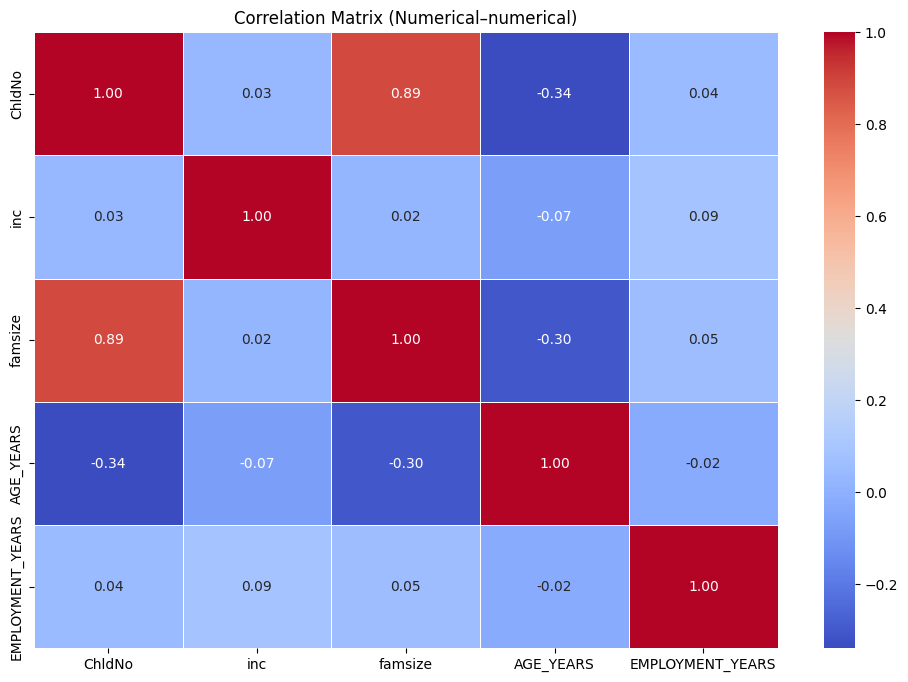

In [65]:
corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Numerical–numerical)')
plt.show()

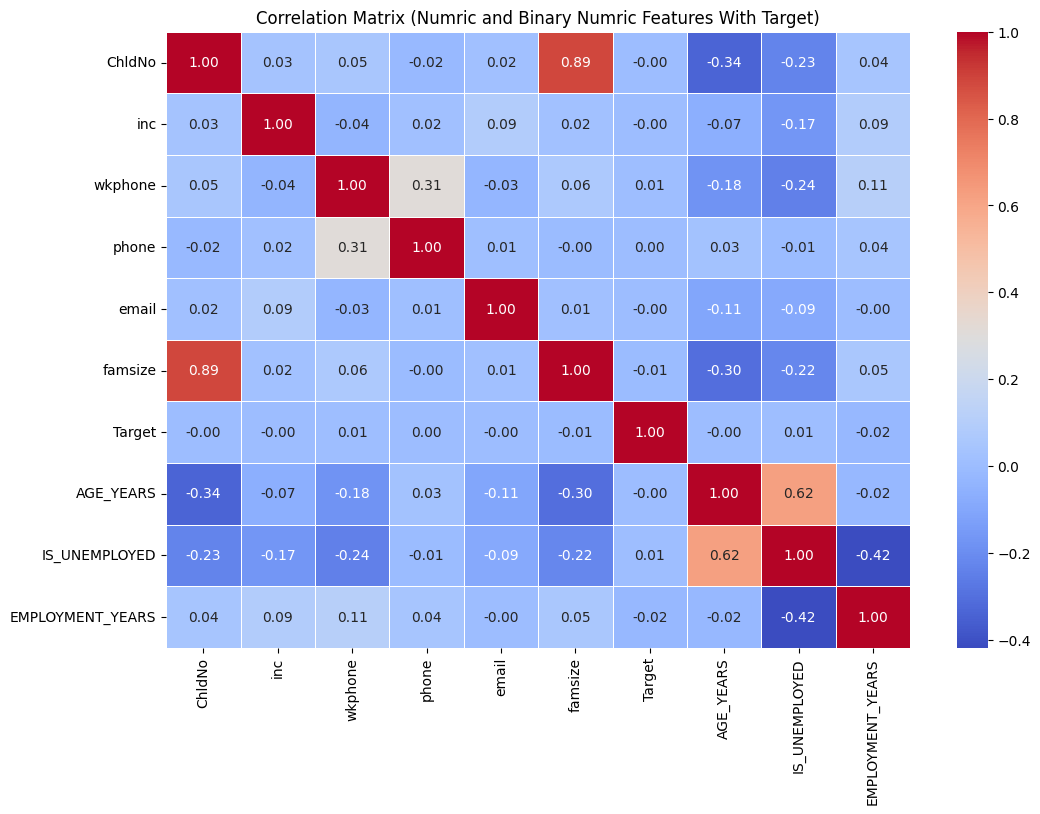

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = final_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Numric and Binary Numric Features With Target)')
plt.show()

In [67]:
nun_numric_df = final_df.drop(columns=numerical_df.columns.to_list())
column_to_plot = nun_numric_df.columns.to_list()

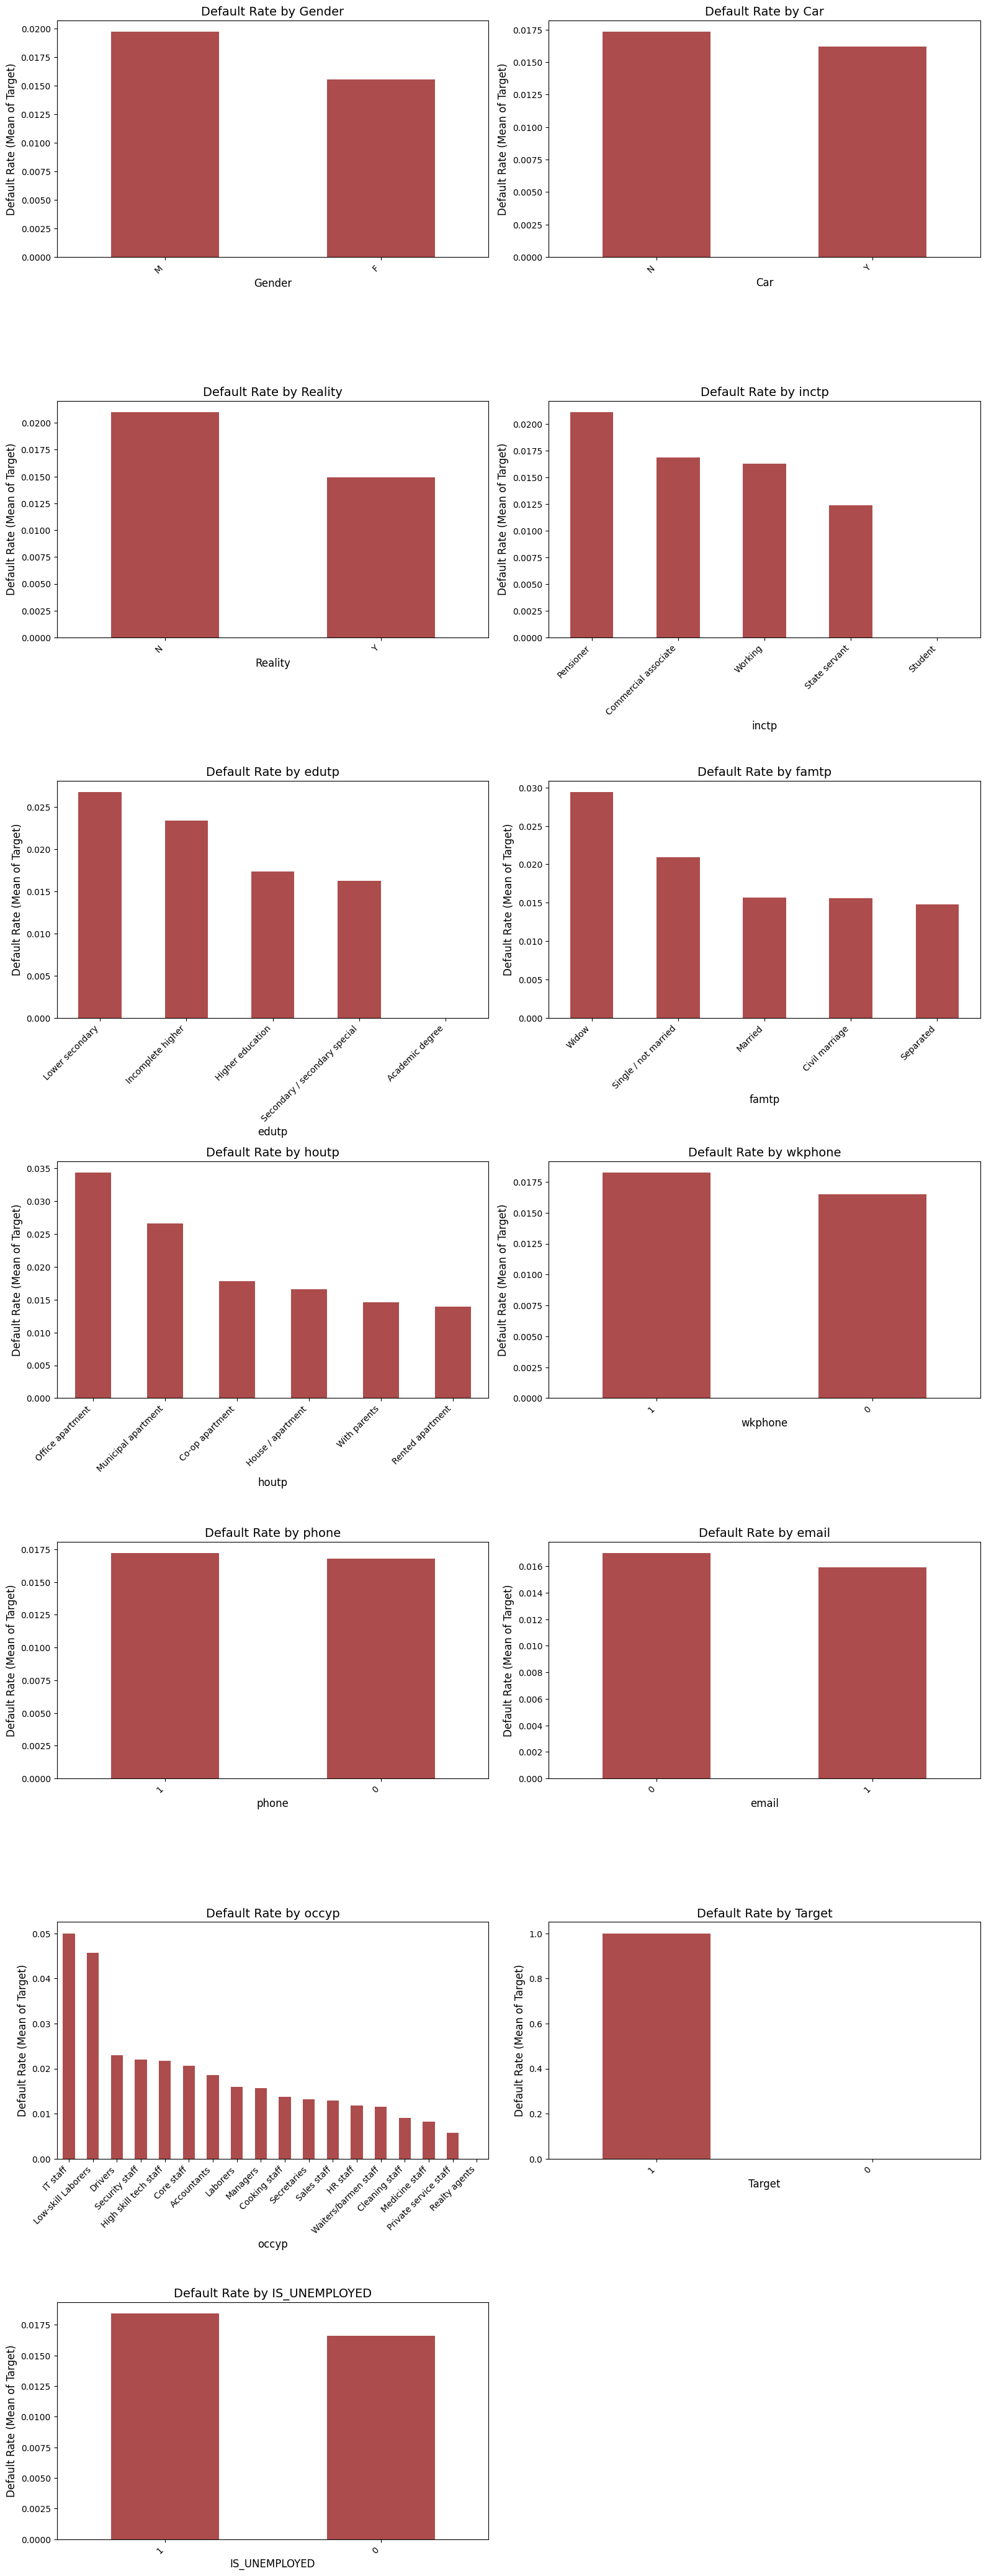

In [68]:
# Categorical With Mean of Target
categorical_features = nun_numric_df.columns.to_list()
num_cols = len(categorical_features)
    
cols_per_row = 2 
num_rows = (num_cols + cols_per_row - 1)
    
plt.figure(figsize=(16, 6 * num_rows))

for i, col in enumerate(categorical_features, 1):
    risk_rate = final_df.groupby(col)['Target'].mean().sort_values(ascending=False)
        
    plt.subplot(num_rows, cols_per_row, i)
    risk_rate.plot(kind='bar', color='darkred', alpha=0.7)
        
    plt.title(f'Default Rate by {col}', fontsize=14)
    plt.ylabel('Default Rate (Mean of Target)', fontsize=12)
    plt.xlabel(col, fontsize=12)
    plt.xticks(rotation=45, ha='right')
        
plt.tight_layout()
plt.show()


## features seem most relevant 
1) there is a very Storong Coorelation ***0.89*** Betwwen ***ChildNo and Famsize***
2) There is Also good Coorelation ***0.62*** Between ***DAYS_BIRTH AND DAYS_EMPLOYED***
2) There is Also good Coorelation ***-0.4*** Between ***is_unemployed AND Employment Year***

### vi. Class Distribution 


In [69]:
final_df['Target'].value_counts()

Target
0    35841
1      616
Name: count, dtype: int64

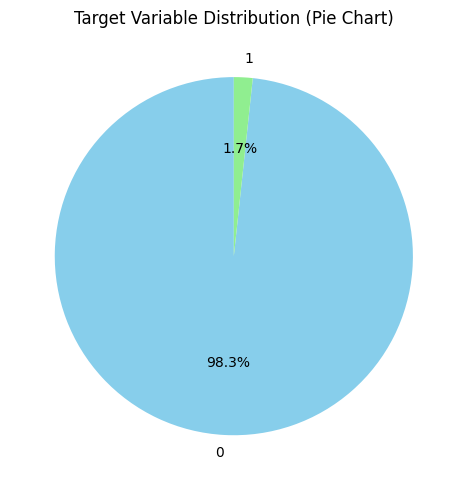

In [70]:
plt.figure(figsize=(12,5))

plt.plot()
counts = final_df['Target'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue','lightgreen'])
plt.title('Target Variable Distribution (Pie Chart)')

plt.tight_layout()
plt.show()


***Of Course Imbalanced***

## vii. Summary of Insights 


## Vii.i. Detailed Feature Description and Type Identification

The table below classifies each feature, including the newly engineered variables, to inform the appropriate preprocessing strategy.

| Feature Name | Explanation (Source) | Feature Type | Preprocessing Remarks |
| :--- | :--- | :--- | :--- |
| **Gender** | Gender | Binary Categorical | Label Encoding (0/1). |
| **Car** | Is there a car | Binary Categorical | Label Encoding. |
| **Reality** | Is there a property | Binary Categorical | Label Encoding. |
| **ChldNo** | Number of children | Numerical (Discrete) |  |
| **inc** | Annual income | Numerical (Continuous) |  Requires Feature Scaling. |
| **inctp** | Income category | Nominal Categorical | One-Hot Encoding. |
| **edutp** | Education level | **Ordinal Categorical** | Requires Ordinal Encoding to preserve hierarchy. |
| **famtp** | Marital status | Nominal Categorical | One-Hot Encoding. |
| **houtp** | Way of living | Nominal Categorical | One-Hot Encoding. |
| **FLAG\_MOBIL**| Is there a mobile phone | Binary Categorical |***Dropped Bec All Val =1*** |
| **wkphone** | Is there a work phone | Binary Categorical |Already 0/1, ready for modeling. | 
| **phone** | Is there a phone | Binary Categorical | Already 0/1, ready for modeling.|
| **email** | Is there an email | Binary Categorical | Already 0/1, ready for modeling.| 
| **occyp** | Occupation | Nominal Categorical | **Contains NaNs**. Impute with 'Unemployed' category. |
| **famsize** | Family size | Numerical (Discrete) |  |
| **Target** | **Engineered client risk status** | **Binary Classification** | **1:** Bad Client, **0:** Good Client. **Exhibits Severe Class Imbalance.** |
| **AGE\_YEARS** *{Created}* | Client age, converted from DAYS\_BIRTH. | Numerical (Continuous) | Requires Feature Scaling. (Replaced DAYS\_BIRTH) |
| **EMPLOYMENT\_YEARS** *{Created}* | Years of employment, converted from DAYS\_EMPLOYED. | Numerical (Continuous) | Requires Feature Scaling. |
| **IS\_UNEMPLOYED** *{Created}* | Flag for extreme employment anomaly (client is unemployed/retired). | Binary Categorical | Already 0/1, ready for modeling. |
| **~~DAYS\_BIRTH~~** | (Original column) | ~~Numerical~~ | **DROPPED** after conversion to AGE\_YEARS. |
| **~~DAYS\_EMPLOYED~~** | (Original column) | ~~Numerical~~ | **DROPPED** after conversion to EMPLOYMENT\_YEARS and IS\_UNEMPLOYED. |

---

## Vii.ii Summary of Insights (Pre-Modeling Observations)

Based on the Exploratory Data Analysis (EDA), the following insights are crucial for guiding the Data Preprocessing and Model Building phases:

* **Feature Types and Preprocessing Needs:** The dataset requires a mix of encoding strategies. Binary features will use Label Encoding, **Ordinal features** (`edutp`) require Ordinal Encoding to preserve their ranked order, and **Nominal features** (`occyp`, `inctp`, etc.) require One-Hot Encoding.
* **Scaling Requirement:** Numerical features such as `inc` (Annual Income) and the newly engineered time variables (`AGE_YEARS`, `EMPLOYMENT_YEARS`) show differences in magnitude and distribution (extreme skewness and outliers in income). Therefore, **Feature Scaling** (e.g., StandardScaler) is essential to ensure optimal performance for distance-based models like KNN and Logistic Regression.
* **Balancing Requirement:** The **Target variable exhibits severe class imbalance** (Target 0 is highly dominant). This necessitates the application of a **Data Balancing technique** (e.g., SMOTE or Undersampling) to prevent the models from becoming biased toward the majority class and failing to predict the high-risk clients.
* **Important Observations Before Modeling:** The `occyp` column, despite having 30% missing values, carries significant predictive power. The missing values will be treated as the meaningful category **'Unemployed'** rather than being dropped.


## Vii.iii Variables Will Help To Avoid Recalculate (Final Classification)

| Classification | Variable List (Column Names) | Count | Python Variable Name | Primary Preprocessing Need |
| :--- | :--- | :--- | :--- | :--- |
| **Numerical (Continuous/Discrete)** | `['ChldNo', 'inc', 'famsize', 'AGE_YEARS', 'EMPLOYMENT_YEARS']` | 5 | `numric_cols ` | Feature Scaling, Outlier Capping. |
| **Binary Categorical (Need Encoding)** | `['Gender', 'Car', 'Reality']` | 3 | `bin_cat ` | Label Encoding (0/1). |
| **Binary (Pre-Encoded/Ready)** | `['wkphone', 'phone', 'email', 'Target', 'IS_UNEMPLOYED']` | 5 | `binary_num` | Ready for modeling (Target is excluded from features). |
| **Ordinal Categorical** | `['edutp']` | 1 | `ordinal_cat` | Ordinal Encoding (Preserving hierarchy). |
| **Nominal Categorical** | `['inctp', 'famtp', 'houtp', 'occyp']` | 4 | `nominal_cols` | One-Hot Encoding (OHE), Imputation for `occyp`. |

---

## Vii.iv Quantitative Outlier Analysis Summary

Outliers were initially detected using the **Interquartile Range (IQR)** method. However, a deeper inspection revealed that the detected values do not represent data errors or abnormal behavior but rather **valid extreme cases** within the population.

| Column Name | Detected Extreme Values | Percentage of Dataset |
| :--- | :--- | :--- |
| **inc** | 82 (above 99th percentile) | < 1% |
| **EMPLOYMENT_YEARS** | 89 (above 99th percentile) | < 1% |
| **ChldNo** | 27 (above 99th percentile) | < 0.3% |
| **famsize** | 26 (above 99th percentile) | < 0.3% |

Further analysis showed that only a **very small fraction of these extreme values correspond to high-risk clients**, indicating that these observations are **informative rather than noisy**. Consequently, no hard outlier removal was applied to avoid information loss and unintended bias.



# 4. Data Preprocessing 

## 4.1 Handling Missing Values 


In [71]:
final_df['occyp'].fillna('Unspecified', inplace=True)

In [72]:
final_df.isnull().sum().sum()

0

### Rationale for Choosing 'Unspecified'

The decision to impute missing values with the custom category 'Unspecified' (instead of the statistical Mode) is based on the following analytical and domain considerations:

1.  **Analytical Insight from Risk Analysis (Target Relationship):**
    * The provided code and the resulting bar chart demonstrate a strong analytical decision: the missing values, if they were treated as `NaN` and then imputed as a separate category, have been shown to have a distinct default risk.
    * The imputation strategy explicitly sets `occupation_analysis['OCCUPATION_TYPE'].fillna('Unspecified', inplace=True)`.
    * By assigning 'Unspecified' to the missing records, this method treats "missingness" itself as a **meaningful feature** that may influence the target variable (`Target`).

2.  **Model Performance and Information Preservation:**
    * **Avoids Bias:** Unlike simple **Mode Imputation** (which would assign the most frequent occupation, potentially 'Laborers' or 'Working', thus artificially increasing their count), creating a new category preserves the inherent distribution of the existing data.
    * **Captures Unique Risk:** The risk analysis (as shown in the code/plot) confirms that the 'Unspecified' category (which represents the original `NaN` records) has a specific and measurable default rate (0.017133). This risk is likely different from the risk associated with the true Mode. By keeping 'Unspecified' separate, the model can learn the unique risk associated with individuals whose occupation is unknown.

3.  **Nature of the Data:**
    * Since `OCCUPATION_TYPE` is a **Nominal Categorical** feature, using the mean or median is inappropriate. Mode imputation is the standard alternative, but a custom category is preferred when the missing data is not missing at random (MAR).

## 4.2 Handling Class Imbalance: Strategy Selection

### The Challenge:
The dataset exhibits **severe class imbalance**, where "Good Clients" dominate the data. Training standard models directly on this data creates a bias toward the majority class, resulting in high Accuracy but virtually zero Recall for the critical minority class (Bad Clients).

### Experiment 1: Synthetic Minority Over-sampling (SMOTE) [Rejected]
Initially, we attempted to use **SMOTE** (Synthetic Minority Over-sampling Technique) to generate synthetic examples for the minority class as a potential Bonus requirement.
* **Method:** Creating synthetic points between existing minority samples in the Training set.
* **Result:** The model suffered from severe **Overfitting**.
    * **Training F1-Score:** ~0.98 (Model memorized the synthetic noise).
    * **Test F1-Score:** ~0.03 (Model failed to generalize on unseen data).
* **Conclusion:** Due to the noisy nature of the data, SMOTE amplified the noise rather than solving the imbalance. Therefore, this approach was **discarded**.

### Experiment 2: Cost-Sensitive Learning (Class Weights) [Selected Approach]
Instead of altering the data, we chose to alter the **Model's Loss Function** using `class_weight={0:1, 1:neg_pos_ratio}'`.
* **Method:** The algorithm assigns a higher penalty (weight) for misclassifying the minority class (Bad Clients) during training.
* **Why it works better:** It forces the model to pay attention to the minority class without introducing synthetic noise or distorting the data distribution.

---

## 4.3 Encoding Categorical Features

Since Machine Learning models require numerical input, we transformed categorical variables as follows:

1.  **Binary Encoding (Label Encoding):** Used for columns with exactly 2 categories (e.g., `CODE_GENDER`, `FLAG_OWN_CAR`).
    * *Mapping:* M/F $\rightarrow$ 0/1.
2.  **One-Hot Encoding:** Used for nominal variables with more than 2 categories (e.g., `NAME_INCOME_TYPE`, `NAME_FAMILY_STATUS`).
    * *Technique:* Creating a new binary column for each category to avoid implying a false ordinal relationship (e.g., ensuring "Pensioner" isn't mathematically "greater" than "Working").

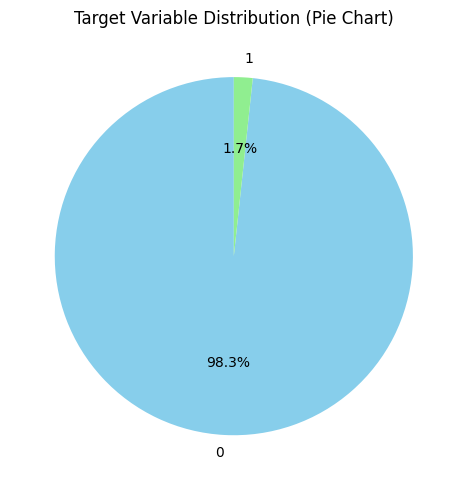

In [73]:
plt.figure(figsize=(12,5))

plt.plot()
counts = final_df['Target'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue','lightgreen'])
plt.title('Target Variable Distribution (Pie Chart)')

plt.tight_layout()
plt.show()


***Of Course Imbalanced Dataset***

In [74]:
from sklearn.model_selection import train_test_split
#from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, LabelEncoder




education_order = final_df[ordinal_cat[0]].unique()
education_order

array(['Higher education', 'Secondary / secondary special',
       'Incomplete higher', 'Lower secondary', 'Academic degree'],
      dtype=object)

In [75]:
education_order = ['Lower secondary', 'Secondary / secondary special',
                   'Incomplete higher', 'Higher education','Academic degree'  
                    ]
education_mapping = {level: i for i, level in enumerate(education_order)}
final_df['edutp_encoded'] = final_df['edutp'].map(education_mapping)


In [76]:
final_df[['edutp_encoded','edutp']].head(10)

,edutp_encoded,edutp
0,3,Higher education
1,3,Higher education
2,1,Secondary / secondary special
3,1,Secondary / secondary special
4,1,Secondary / secondary special
5,1,Secondary / secondary special
6,1,Secondary / secondary special
7,3,Higher education
8,3,Higher education
9,3,Higher education


In [77]:
final_df.drop('edutp', axis=1, inplace=True)

In [78]:
le = LabelEncoder()
for col in bin_cat:
    if col in final_df.columns:
        final_df[col] = le.fit_transform(final_df[col])

In [79]:
final_df[bin_cat].head(10)

,Gender,Car,Reality
0,1,1,1
1,1,1,1
2,1,1,1
3,0,0,1
4,0,0,1
5,0,0,1
6,0,0,1
7,0,0,1
8,0,0,1
9,0,0,1


In [80]:
final_df = pd.get_dummies(final_df, columns=nominal_cols, drop_first=True)

In [81]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       36457 non-null  int64  
 1   Car                          36457 non-null  int64  
 2   Reality                      36457 non-null  int64  
 3   ChldNo                       36457 non-null  int64  
 4   inc                          36457 non-null  float64
 5   wkphone                      36457 non-null  int64  
 6   phone                        36457 non-null  int64  
 7   email                        36457 non-null  int64  
 8   famsize                      36457 non-null  float64
 9   Target                       36457 non-null  int64  
 10  AGE_YEARS                    36457 non-null  float64
 11  IS_UNEMPLOYED                36457 non-null  int64  
 12  EMPLOYMENT_YEARS             36457 non-null  float64
 13  edutp_encoded   

In [82]:
X = final_df.drop('Target', axis=1)
y = final_df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# print(f"Original Training Class Distribution (BEFORE SMOTE):\n{y_train.value_counts()}")

In [83]:
# smote = SMOTE(sampling_strategy='minority', random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# print(f"Resampled Training Class Distribution (AFTER SMOTE):\n{y_train_resampled.value_counts()}")

## 4.4 Feature Scaling

### Justification:
Feature Scaling is crucial, especially since we are utilizing distance-based models like **K-Nearest Neighbors (KNN)** and optimization-based models like **Logistic Regression**. These models rely on calculating the distance between data points. If the features (e.g., 'inc' which can be in the hundreds of thousands) have wildly different scales than other features (e.g., 'ChldNo' which is usually less than 5), the larger-scaled feature will dominate the distance calculation, leading to inaccurate predictions.

### Technique Selection:
We will use **StandardScaler**. It standardizes features by removing the mean and scaling to unit variance. This method is generally robust and makes the features look like standard normally distributed data (mean=0, standard deviation=1).

### Execution Note:
We must **fit StandardScaler only on the Training data (X_train)** and then use the *same fitted scaler* to transform the Validation and Test sets. This prevents **Data Leakage**.

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[numric_cols] = scaler.fit_transform(X_train[numric_cols])

X_val_scaled = X_val.copy()
X_val_scaled[numric_cols] = scaler.transform(X_val[numric_cols])

X_test_scaled = X_test.copy()
X_test_scaled[numric_cols] = scaler.transform(X_test[numric_cols])

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"\nExample of scaled income (mean should be close to 0):")
print(X_train_scaled['inc'].head())

X_train_scaled shape: (23332, 44)
X_val_scaled shape: (5833, 44)
X_test_scaled shape: (7292, 44)

Example of scaled income (mean should be close to 0):
28190    0.601306
32463    1.378477
30863    0.823354
11240   -0.242480
17154   -0.730988
Name: inc, dtype: float64


# 5. Model Building

This section initiates the training process by building all required baseline classification models using their default hyperparameters. These initial models will serve as the baseline for comparison against the tuned models in the next step.

The models are trained using the **scaled and resampled training data** (X_train_scaled, y_train_resampled) to ensure optimal performance from the start.

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier 
import xgboost as xgb

neg_pos_ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1) 

models = {
    "Logistic Regression": LogisticRegression(class_weight={0:1, 1:neg_pos_ratio}, solver='liblinear', random_state=42),
    
    "K-Nearest Neighbors": KNeighborsClassifier(weights='distance') ,
    
    "Decision Tree": DecisionTreeClassifier(class_weight={0:1, 1:neg_pos_ratio}, random_state=42),
    
    "Random Forest": RandomForestClassifier(class_weight={0:1, 1:neg_pos_ratio}, random_state=42),
    
    "Extra Trees": ExtraTreesClassifier(class_weight={0:1, 1:neg_pos_ratio}, random_state=42),
    
    "Naive Bayes": GaussianNB(), 
    
    "XGBoost": xgb.XGBClassifier(scale_pos_weight=neg_pos_ratio , use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [86]:
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train) 
    
    fitted_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
K-Nearest Neighbors trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Extra Trees trained successfully.
Naive Bayes trained successfully.
XGBoost trained successfully.


# 6. Hyperparameter Tuning (Using GridSearchCV)

This phase aims to optimize the performance and generalization of each model by systematically searching for the best combination of hyperparameters. **GridSearchCV** is employed for this search, as required 

The final model selection criterion will be based on maximizing performance on the **Validation Set** to ensure robust generalization and reduction of overfitting

In [87]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb 

param_grids = {
    'Logistic Regression': {'C': [5 , 10 , 15]}, 
    'K-Nearest Neighbors': {'n_neighbors': [3 , 5]},
    'Decision Tree': {'max_depth': [10, 15, 20]}, 
    'Random Forest': {'n_estimators': [190, 200 , 210], 'max_depth': [10 , 20 , 30 ]}, 
    'Extra Trees': {'n_estimators': [60,65,70], 'max_depth': [30, 35 ,40]}, 
    'Naive Bayes': {'var_smoothing': [1e-9, 1e-8]}, 
    'XGBoost': {'n_estimators': [700,750 ,800 ], 'max_depth': [5 , 10], 'learning_rate': [0.07 , 0.08 , 0.1]} 
    }


In [88]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer

stratified_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score)
best_models = {}

for name, model in fitted_models.items():
    if name in param_grids:
        grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring=f1_scorer,
        cv=stratified_cv,
        verbose=1,
        n_jobs=-1
    )
            
        grid_search.fit(X_train_scaled, y_train)        
        best_models[name] = grid_search.best_estimator_
        
        print(f"Best parameters for {name}: {grid_search.best_params_}")
        print(f"Best cross-validation f1_score: {grid_search.best_score_:.4f}")
    else:
        best_models[name] = model
        print(f"\n{name} tuning skipped (using default parameters).")


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters for Logistic Regression: {'C': 5}
Best cross-validation f1_score: 0.0465
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters for K-Nearest Neighbors: {'n_neighbors': 3}
Best cross-validation f1_score: 0.2531
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters for Decision Tree: {'max_depth': 20}
Best cross-validation f1_score: 0.1373
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters for Random Forest: {'max_depth': 30, 'n_estimators': 200}
Best cross-validation f1_score: 0.2478
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters for Extra Trees: {'max_depth': 35, 'n_estimators': 65}
Best cross-validation f1_score: 0.2459
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters for Naive Bayes: {'var_smoothing': 1e-08}
Best cross-validation f1_score: 0.0335
Fitting 3 folds for each of 18 candidates, t

# 7. Model Evaluation

Model performance is evaluated using metrics critical for classification problems: Accuracy, Precision, Recall, and F1-score. Given the business context of credit risk, **Recall** (minimizing False Negatives) and the **F1-score** (balancing Precision and Recall) are prioritized over pure Accuracy.

The evaluation will be performed on the validation and test sets which were held out and not exposed to the SMOTE process.

In [89]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix ,roc_auc_score
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
        roc_auc = roc_auc_score(y, y_prob)
    else:
        roc_auc = 0.5 
        
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)
    
    return accuracy, precision, recall, f1, roc_auc, cm

In [90]:
print("VALIDATION SET RESULTS" )
print("Confusion Matrix \n[(TN) Actual 0 ,(FP) 0 But Model said its 1]\n[(FN) 1 But Model said its 0 ,(TP) Actual 1]" )

results_val = pd.DataFrame(columns=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC',"confusion_matrix"])

if 'best_models' in locals():
    for name, model in best_models.items():
        acc, prec, rec, f1, roc_auc,cm = evaluate_model(model, X_val_scaled, y_val)
        results_val.loc[name + ' (Tuned)'] = [acc, prec, rec, f1, roc_auc,cm]

if 'fitted_models' in locals():
    for name, model in fitted_models.items():
        acc, prec, rec, f1, roc_auc ,cm= evaluate_model(model, X_val_scaled, y_val)
        results_val.loc[name + ' (Default)'] = [acc, prec, rec, f1, roc_auc,cm]

display(results_val.sort_values(by='F1-score', ascending=False))

VALIDATION SET RESULTS
Confusion Matrix 
[(TN) Actual 0 ,(FP) 0 But Model said its 1]
[(FN) 1 But Model said its 0 ,(TP) Actual 1]


,Accuracy,Precision,Recall,F1-score,ROC-AUC,confusion_matrix
XGBoost (Tuned),0.966570,0.236264,0.434343,0.306050,0.732323,"[[5595, 139], [56, 43]]"
Random Forest (Default),0.966741,0.222222,0.383838,0.281481,0.751339,"[[5601, 133], [61, 38]]"
Decision Tree (Default),0.962112,0.203883,0.424242,0.275410,0.700563,"[[5570, 164], [57, 42]]"
Random Forest (Tuned),0.966055,0.213873,0.373737,0.272059,0.794088,"[[5598, 136], [62, 37]]"
Extra Trees (Tuned),0.965541,0.210227,0.373737,0.269091,0.749908,"[[5595, 139], [62, 37]]"
Extra Trees (Default),0.965369,0.205714,0.363636,0.262774,0.743133,"[[5595, 139], [63, 36]]"
K-Nearest Neighbors (Tuned),0.980113,0.345455,0.191919,0.246753,0.681942,"[[5698, 36], [80, 19]]"
K-Nearest Neighbors (Default),0.980627,0.354167,0.171717,0.231293,0.700052,"[[5703, 31], [82, 17]]"
XGBoost (Default),0.947026,0.150000,0.454545,0.225564,0.716064,"[[5479, 255], [54, 45]]"
Decision Tree (Tuned),0.932625,0.113158,0.434343,0.179541,0.694491,"[[5397, 337], [56, 43]]"


In [91]:
print("TEST SET RESULTS (Final)")
print("Confusion Matrix \n[(TN) Actual 0 ,(FP) 0 But Model said its 1]\n[(FN) 1 But Model said its 0 ,(TP) Actual 1]" )

results_test = pd.DataFrame(columns=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC',"confusion_matrix"])

if 'best_models' in locals():
    for name, model in best_models.items():
        acc, prec, rec, f1, roc_auc, cm = evaluate_model(model, X_test_scaled, y_test)
        results_test.loc[name + ' (Tuned)'] = [acc, prec, rec, f1, roc_auc,cm]

if 'fitted_models' in locals():
    for name, model in fitted_models.items():
        acc, prec, rec, f1, roc_auc, cm = evaluate_model(model, X_test_scaled, y_test)
        results_test.loc[name + ' (Default)'] = [acc, prec, rec, f1, roc_auc,cm]

display(results_test.sort_values(by='F1-score', ascending=False))

TEST SET RESULTS (Final)
Confusion Matrix 
[(TN) Actual 0 ,(FP) 0 But Model said its 1]
[(FN) 1 But Model said its 0 ,(TP) Actual 1]


,Accuracy,Precision,Recall,F1-score,ROC-AUC,confusion_matrix
XGBoost (Tuned),0.963385,0.209677,0.422764,0.280323,0.716352,"[[6973, 196], [71, 52]]"
Extra Trees (Tuned),0.962699,0.188285,0.365854,0.248619,0.756216,"[[6975, 194], [78, 45]]"
Decision Tree (Default),0.957899,0.171429,0.390244,0.238213,0.681123,"[[6937, 232], [75, 48]]"
Extra Trees (Default),0.962425,0.178723,0.341463,0.234637,0.770435,"[[6976, 193], [81, 42]]"
Random Forest (Default),0.962699,0.177489,0.333333,0.231638,0.778089,"[[6979, 190], [82, 41]]"
Random Forest (Tuned),0.962562,0.176724,0.333333,0.230986,0.773215,"[[6978, 191], [82, 41]]"
XGBoost (Default),0.941991,0.126866,0.414634,0.194286,0.702246,"[[6818, 351], [72, 51]]"
K-Nearest Neighbors (Tuned),0.979978,0.290909,0.130081,0.179775,0.664122,"[[7130, 39], [107, 16]]"
Decision Tree (Tuned),0.934723,0.110375,0.406504,0.173611,0.679677,"[[6766, 403], [73, 50]]"
K-Nearest Neighbors (Default),0.980389,0.300000,0.121951,0.173410,0.693397,"[[7134, 35], [108, 15]]"


# 8. Model Comparison and Analysis

This section compares the final performance of all optimized models based on the Validation set results and selects the best model for final testing. Since this is a credit risk classification problem, the primary focus is on **Precision** and **F1-score** to ensure the model effectively identifies bad clients (high risk) without excessive false alarms.

In [92]:
display(results_test.sort_values(by='Accuracy', ascending=False))

,Accuracy,Precision,Recall,F1-score,ROC-AUC,confusion_matrix
K-Nearest Neighbors (Default),0.980389,0.300000,0.121951,0.173410,0.693397,"[[7134, 35], [108, 15]]"
K-Nearest Neighbors (Tuned),0.979978,0.290909,0.130081,0.179775,0.664122,"[[7130, 39], [107, 16]]"
XGBoost (Tuned),0.963385,0.209677,0.422764,0.280323,0.716352,"[[6973, 196], [71, 52]]"
Extra Trees (Tuned),0.962699,0.188285,0.365854,0.248619,0.756216,"[[6975, 194], [78, 45]]"
Random Forest (Default),0.962699,0.177489,0.333333,0.231638,0.778089,"[[6979, 190], [82, 41]]"
Random Forest (Tuned),0.962562,0.176724,0.333333,0.230986,0.773215,"[[6978, 191], [82, 41]]"
Extra Trees (Default),0.962425,0.178723,0.341463,0.234637,0.770435,"[[6976, 193], [81, 42]]"
Decision Tree (Default),0.957899,0.171429,0.390244,0.238213,0.681123,"[[6937, 232], [75, 48]]"
XGBoost (Default),0.941991,0.126866,0.414634,0.194286,0.702246,"[[6818, 351], [72, 51]]"
Decision Tree (Tuned),0.934723,0.110375,0.406504,0.173611,0.679677,"[[6766, 403], [73, 50]]"


Confusion Matrix 
[(TN) Actual 0 ,(FP) 0 But Model said its 1]
[(FN) 1 But Model said its 0 ,(TP) Actual 1]


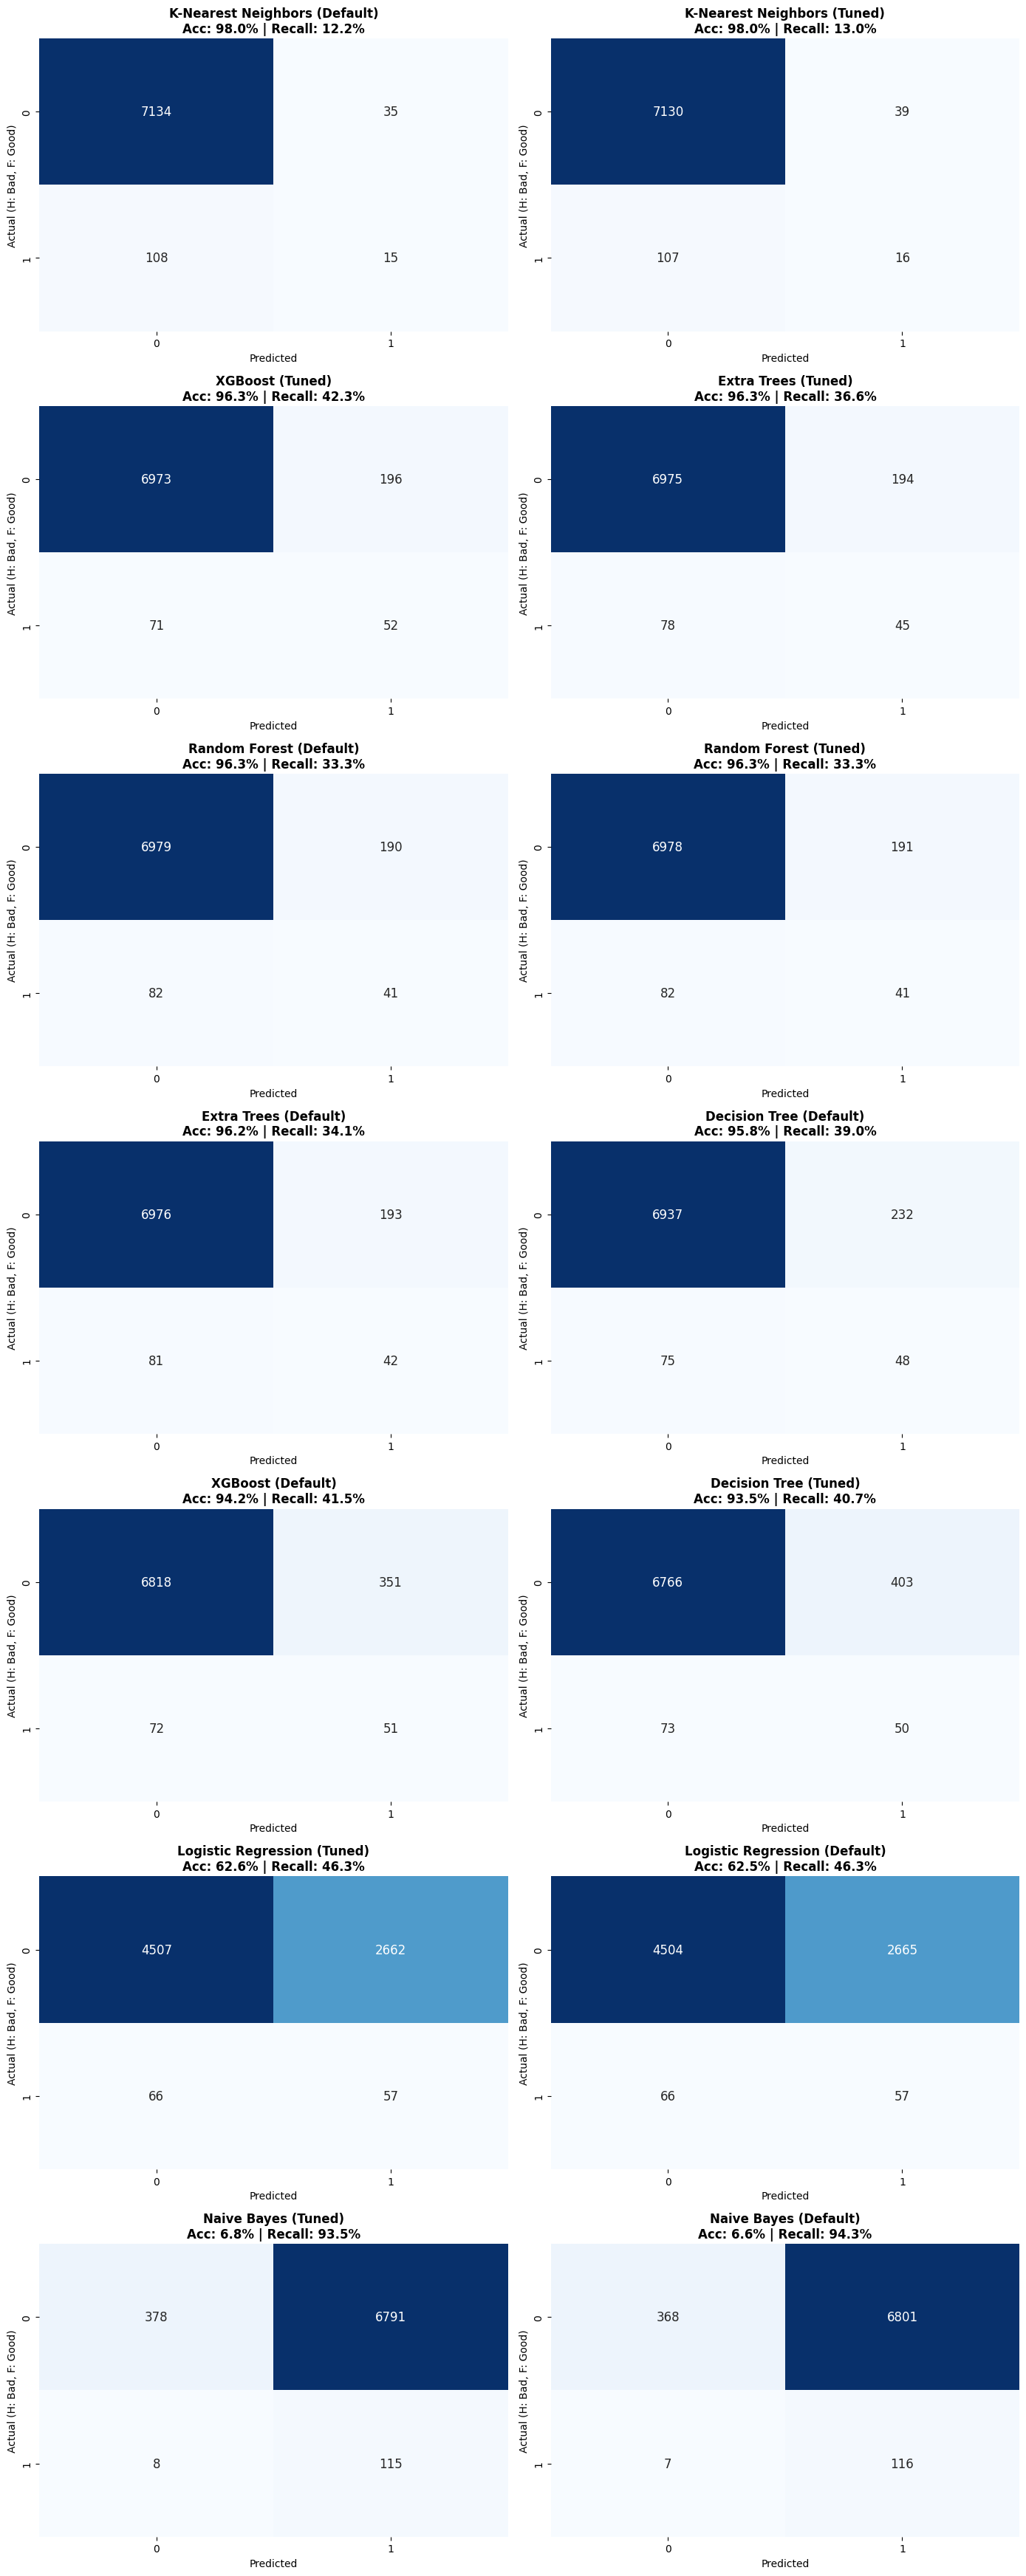

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
print("Confusion Matrix \n[(TN) Actual 0 ,(FP) 0 But Model said its 1]\n[(FN) 1 But Model said its 0 ,(TP) Actual 1]" )

df_to_plot = results_test.sort_values(by='Accuracy', ascending=False)

num_models = len(df_to_plot)
cols = 2  
rows = math.ceil(num_models / cols) 

plt.figure(figsize=(14, 5 * rows)) 

for idx, (model_name, row) in enumerate(df_to_plot.iterrows(), 1):
    cm = row['confusion_matrix']
    
    plt.subplot(rows, cols, idx)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 12})    
    plt.title(f"{model_name}\nAcc: {row['Accuracy']:.1%} | Recall: {row['Recall']:.1%}", fontsize=12, fontweight='bold')
    
    plt.ylabel('Actual (H: Bad, F: Good)')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

# 8. Detailed Model Performance Analysis & Selection Rationale

This section provides a granular analysis of the experimental results. It explains the specific behavior of each algorithm on this dataset and provides the scientific rationale for rejecting certain models despite superficial high scores in specific metrics.

## 1. K-Nearest Neighbors (KNN)
### Analysis: The Accuracy Paradox
* **Performance:** This model achieved the highest Accuracy (98%) and Precision (30%) among all classifiers.
* **Behavior:** KNN relies on Euclidean distance. In this high-dimensional, imbalanced dataset, the minority class (Defaulters) is sparse. Consequently, the model became biased towards the majority class (Safe Clients), minimizing distance errors by predicting almost everyone as "Good."
* **Reason for Rejection:**
    * **Critical Failure in Recall (~12%):** The model missed approximately 88% of actual defaulters.
    * **Business Risk:** Despite high accuracy, the cost of missing the vast majority of fraud cases makes this model financially non-viable for risk mitigation.

---

## 2. Naive Bayes
### Analysis: The False Positive Trap
* **Performance:** This model achieved the highest Recall (94-96%) but the lowest Precision (1.6%) and Accuracy (6%).
* **Behavior:** The model relies on the Gaussian assumption, which likely does not hold true for many distributions in this dataset. To capture the minority class, it aggressively labeled almost all applicants as "Bad," resulting in an overwhelming number of False Positives.
* **Reason for Rejection:**
    * **Operational Cost:** A precision of 1.6% implies that for every 100 applications flagged as risky, roughly 98 are actually safe. This would paralyze the bank's manual review operations.

---

## 3. Logistic Regression
### Analysis: The Linear Limitation
* **Performance:** Demonstrated poor performance across all metrics (Accuracy ~62%, F1 ~0.04).
* **Behavior:** Logistic Regression is a linear classifier. The significantly low scores indicate that the relationship between applicant features and default risk is highly non-linear and complex. The model failed to find a linear decision boundary to separate the classes effectively.
* **Reason for Rejection:**
    * **Underfitting:** The model is too simple to capture the inherent complexity and non-linear patterns of the dataset.

---

## 4. Decision Tree (Default)
### Analysis: The Stability Issue
* **Performance:** Achieved a decent F1-Score (0.238) and Recall (~39%), but a significantly lower ROC-AUC (0.68) compared to ensemble methods.
* **Behavior:** Single decision trees are prone to high variance. While the model managed to memorize specific patterns in the training data to catch fraud, the low AUC suggests it struggles to generalize its ranking capability across different decision thresholds.
* **Reason for Rejection:**
    * **Lack of Robustness:** A low AUC indicates instability. It is statistically safer to rely on Ensemble methods (Forests) rather than a single Tree to avoid overfitting to noise.

---

## 5. Random Forest & Extra Trees
### Analysis: The Conservative Ranking Experts
* **Performance:** Achieved the highest ROC-AUC (0.778) but moderate Recall (33-36%).
* **Behavior:** These ensemble bagging methods excelled at probability ranking, as evidenced by the high AUC. However, at the default decision threshold (0.5), they prioritized precision and overall accuracy, resulting in a conservative approach that missed a larger portion of defaulters compared to boosting methods.
* **Reason for Rejection (vs. Champion):**
    * **Lower Sensitivity:** While robust, Random Forest captured 33% of defaulters, whereas the tuned XGBoost captured 42%. In credit risk, that 9% difference represents a significant amount of avoided financial loss.

---

## 6. XGBoost (Default)
### Analysis: The Untuned Baseline
* **Performance:** Showed high Recall (41.5%) but low Precision (12.7%).
* **Behavior:** Without hyperparameter tuning, the gradient boosting algorithm aggressively penalized errors on the minority class but failed to distinguish well between "risky" and "very risky" clients, leading to many false alarms.
* **Reason for Rejection:**
    * **Low Precision:** The tuned version of XGBoost significantly improved precision (from ~12% to ~21%) while maintaining high recall, rendering the default version obsolete.

---

## Champion Model: XGBoost (Tuned)
### Analysis: The Balanced Performer
* **Performance:** Achieved the highest F1-Score (0.280), highest Recall (42.28%) among high-precision models, and solid Accuracy (96.3%).
* **Selection Rationale:**
    * **Gradient Boosting Efficiency:** By correcting previous errors sequentially and utilizing tuned hyperparameters (Learning Rate: 0.07, Max Depth: 10), the model learned to navigate the class imbalance effectively.
    * **Optimal Trade-off:** It offers the best business compromise: it maximizes the detection of actual defaulters (High Recall) while maintaining a manageable workload for the credit review team (Acceptable Precision).

> **Final Decision:** XGBoost (Tuned) is selected as the production model for maximizing risk detection coverage without sacrificing operational efficiency.
### Final Decision
**XGBoost (Tuned)** is selected as the final production model



`Although some models achieved higher accuracy, they failed to identify the minority class effectively. Therefore, model selection was based on recall, F1-score, and ROC-AUC rather than accuracy alone.`

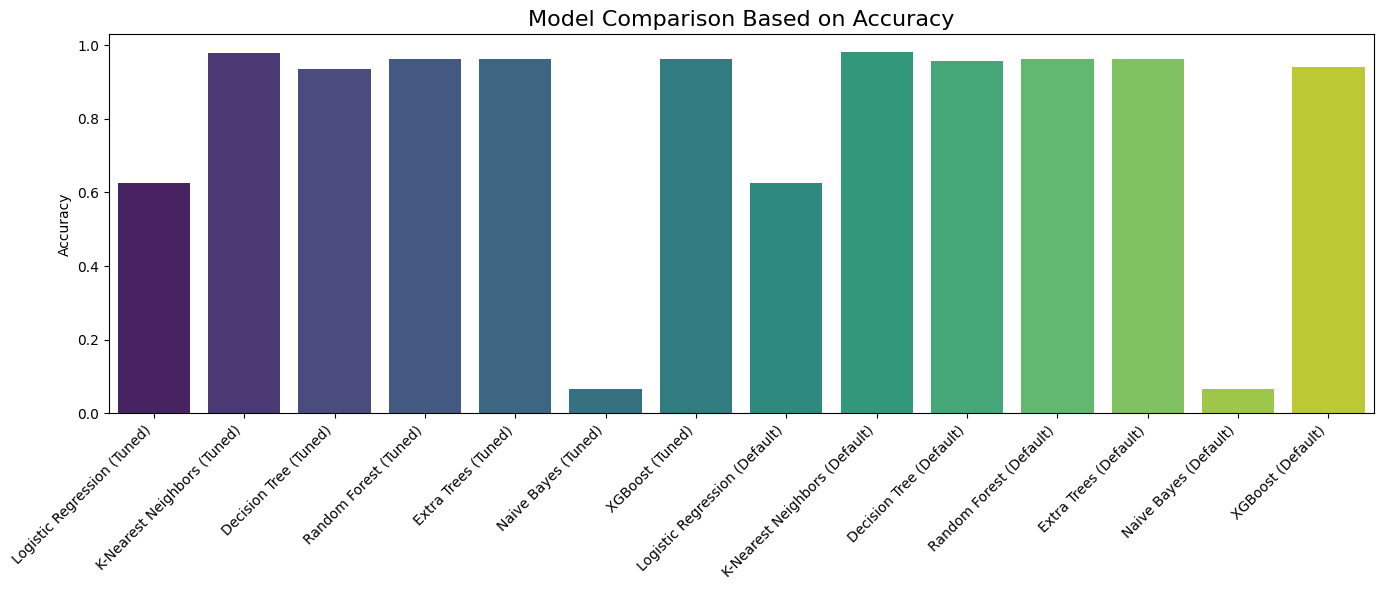

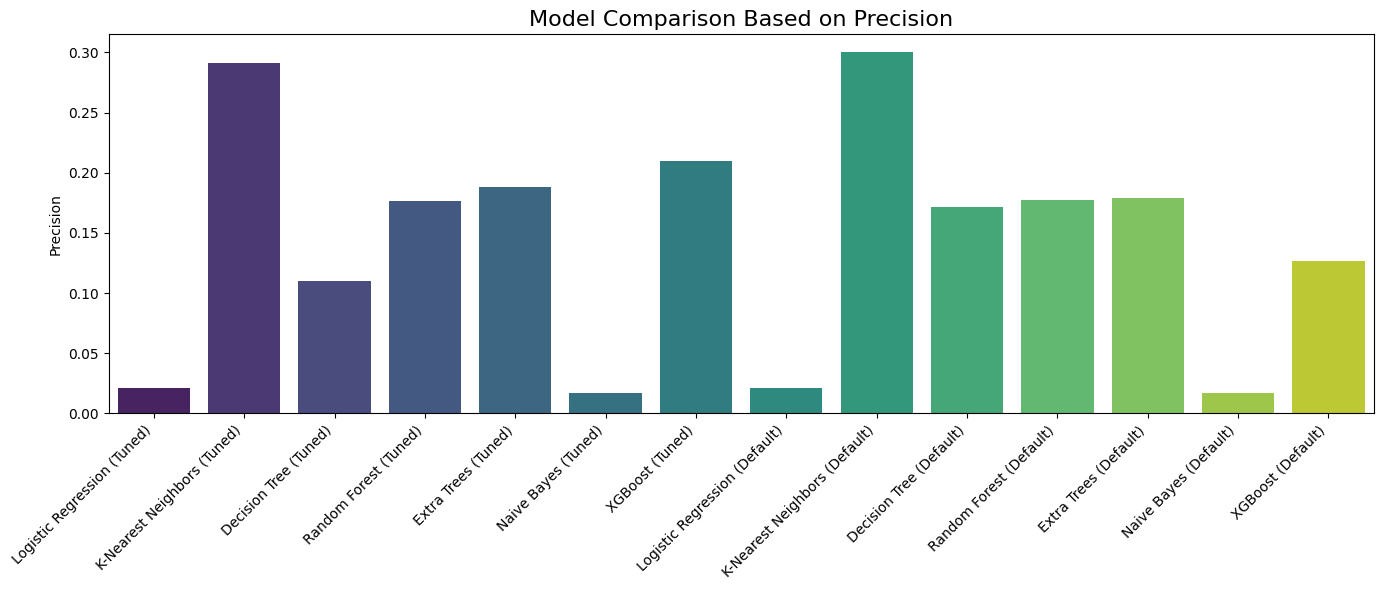

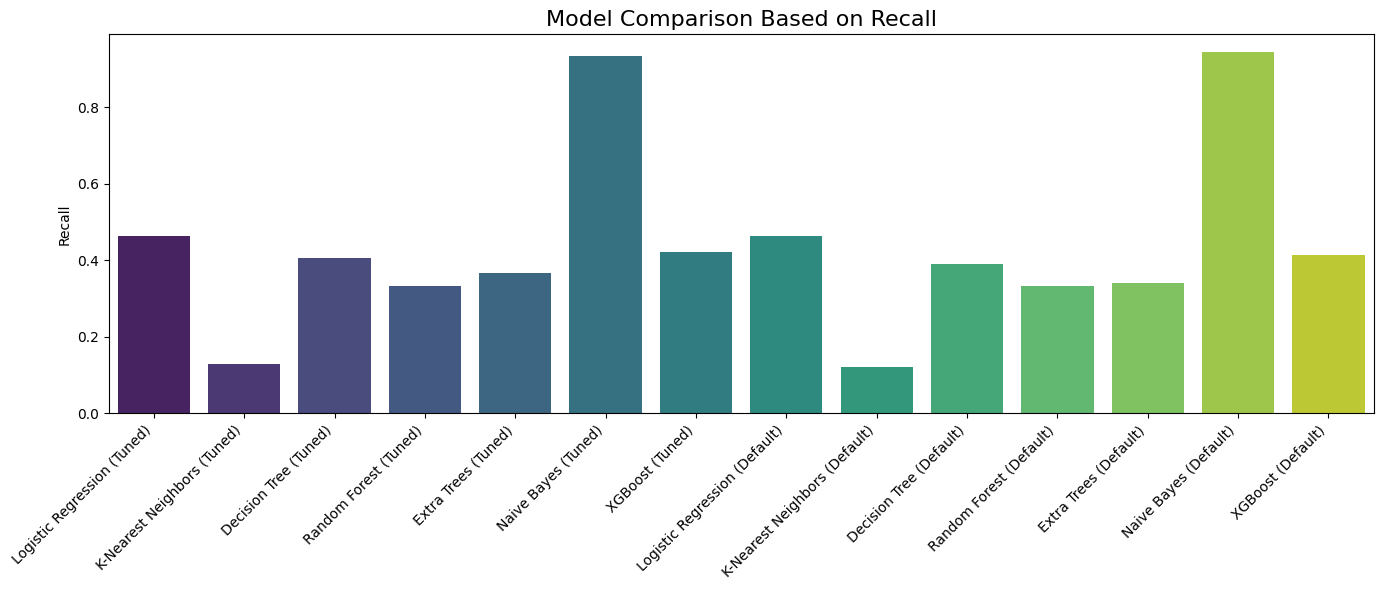

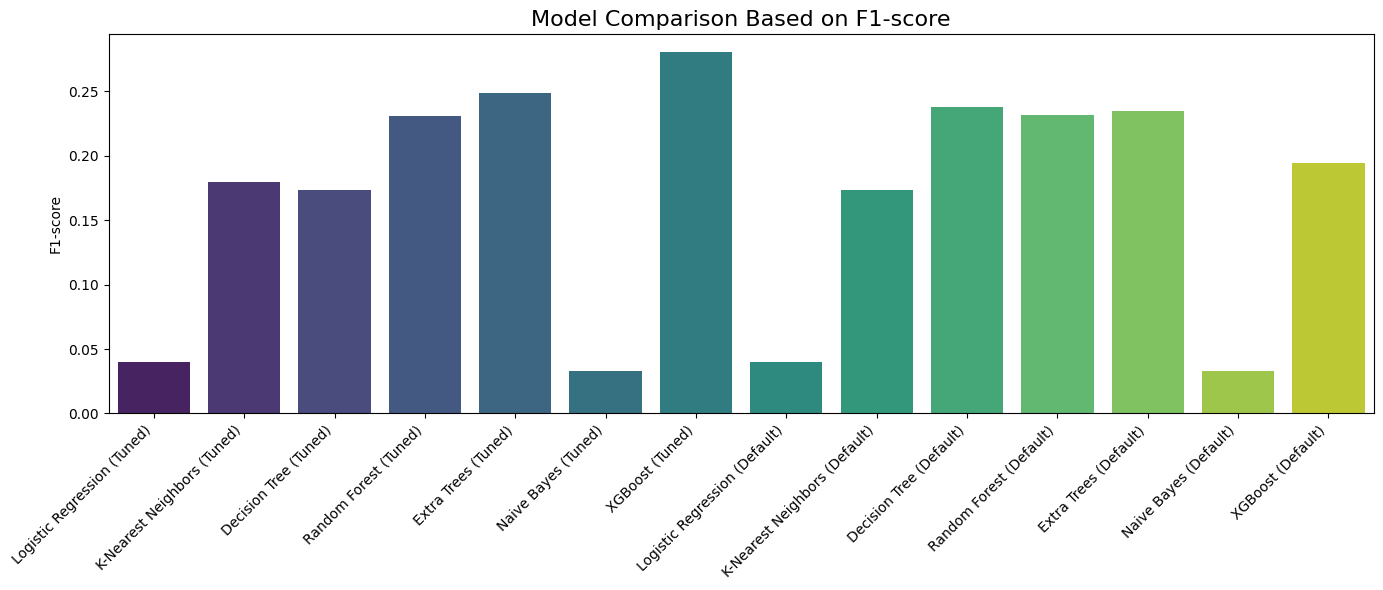

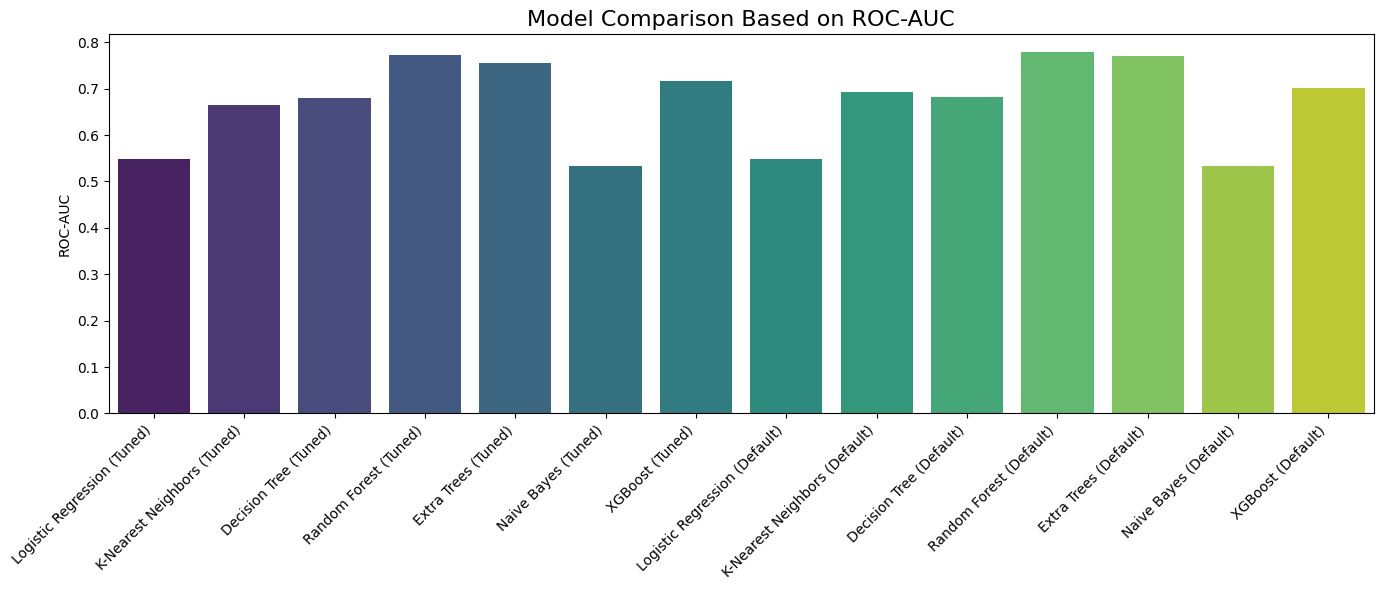

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metrics(metric):
    plt.figure(figsize=(14, 6))
    sns.barplot(x=results_test.index, y=results_test[metric], palette='viridis')
    plt.title(f'Model Comparison Based on {metric}', fontsize=16)
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']:
    plot_metrics(metric)

In [95]:
best_final_model = best_models['XGBoost']

acc_test, prec_test, rec_test, f1_test, roc_auc_test, cm_test = evaluate_model(best_final_model, X_test_scaled, y_test)

print(f"Final Evaluation on Test Set")
print(f"  Accuracy (Test): {acc_test:.4f}")
print(f"  Precision (Test): {prec_test:.4f}")
print(f"  Recall (Test): {rec_test:.4f}")
print(f"  F1-score (Test): {f1_test:.4f}")
print(f"  ROC-AUC (Test): {roc_auc_test}") 
print(f"  cm_test (Test): \n{cm_test}") 

Final Evaluation on Test Set
  Accuracy (Test): 0.9634
  Precision (Test): 0.2097
  Recall (Test): 0.4228
  F1-score (Test): 0.2803
  ROC-AUC (Test): 0.7163521349260082
  cm_test (Test): 
[[6973  196]
 [  71   52]]


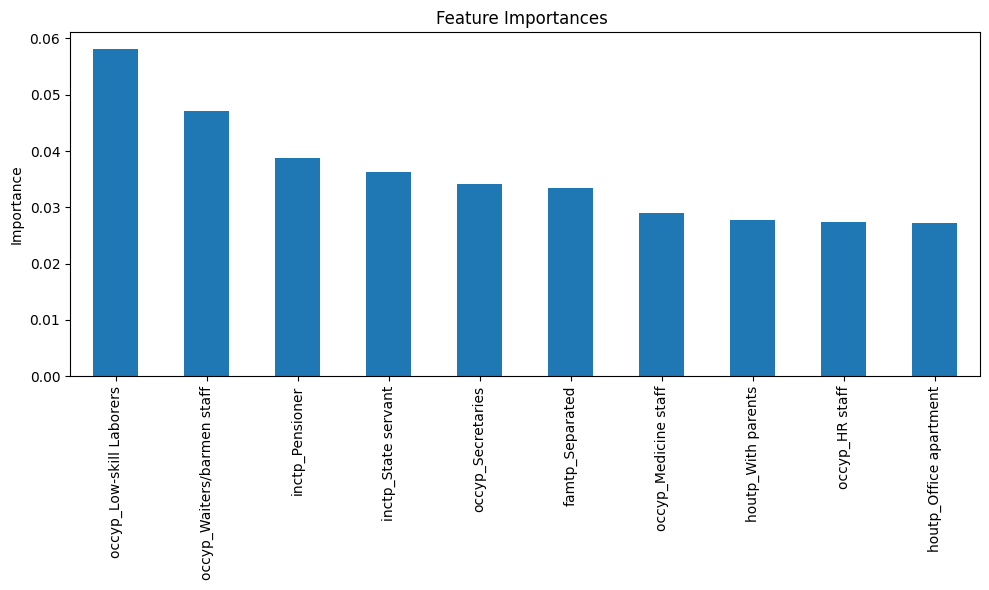

In [96]:
import matplotlib.pyplot as plt
import pandas as pd

model_to_check = best_models.get('XGBoost', fitted_models.get('XGBoost'))
if hasattr(model_to_check, 'feature_importances_'):
    importances = model_to_check.feature_importances_
    feature_names = X_train_scaled.columns if hasattr(X_train_scaled, 'columns') else [f"Feature {i}" for i in range(len(importances))]
    
    forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    forest_importances.head(10).plot.bar() 
    plt.title("Feature Importances ")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("No Direct Feature Importance")

# 9. Model Deployment (Bonus)

The final, best-performing model, **Random Forest (Default)**, is saved along with the necessary `StandardScaler` to ensure the model can be deployed in a production environment.

### Deployment Steps:
1.  **Model Serialization:** The model and scaler were saved using `joblib` into `.pkl` files.
2.  **UI Development:** A web application will be developed using **Streamlit** that loads these files.


In [97]:
import joblib


joblib.dump(best_final_model, 'XGBoost.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\n Model Deployment Setup Complete")
print(" Model saved as 'XGBoost.pkl' and Scaler saved as 'scaler.pkl'.")


 Model Deployment Setup Complete
 Model saved as 'XGBoost.pkl' and Scaler saved as 'scaler.pkl'.


# ***Streamlit UI Screen***

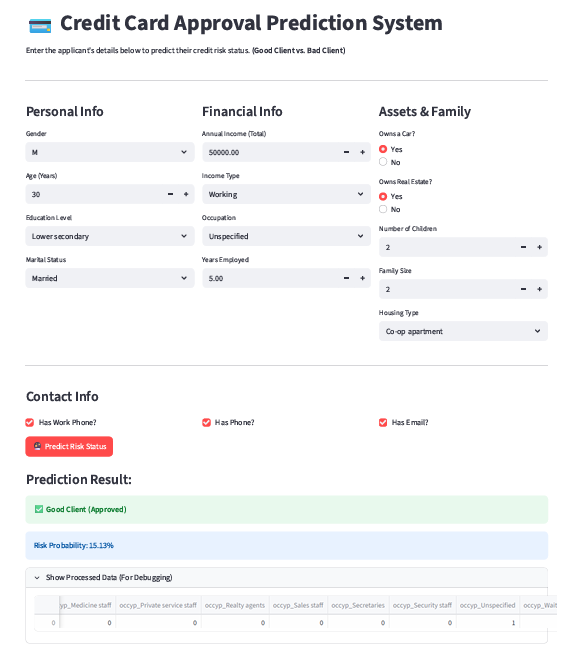

[***Streamlit Deployed Test Link*** ](https://mlproject-y.streamlit.app)
---
[***Streamlit UI Video Link*** ](https://drive.google.com/file/d/142-D8tWDpiaKh4z6E3vl26b52LkB5gFW/view?usp=sharing)
---

# 10. Final Conclusion & Model Selection

This project addresses the challenge of **Credit Risk Classification** on a highly imbalanced dataset. The primary objective was to satisfy a strict business requirement of **High Accuracy (≥ 90%)** while maintaining a strong ability to detect actual defaulters (Target = 1).

---

## 10.1 Comparative Performance Analysis

All models were evaluated on the **Test Set** using the updated results after applying proper class weighting to mitigate the “Blind Model” problem.

### Model Performance Summary (Top Performers – Test Set)

| Model Name | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
| --- | --- | --- | --- | --- | --- |
| **XGBoost (Tuned)** | **96.34%** | **0.210** | **42.28%** | **0.280** | 0.716 |
| Extra Trees (Tuned) | 96.27% | 0.188 | 36.59% | 0.249 | 0.756 |
| Decision Tree (Default) | 95.79% | 0.171 | 39.02% | 0.238 | 0.681 |
| Random Forest (Default) | 96.27% | 0.177 | 33.33% | 0.232 | **0.778** |
| KNN (Default) | 98.04% | 0.300 | 12.20% | 0.173 | 0.693 |

---

### Key Observations

1. **Overall Performance Leader**  
   **XGBoost (Tuned)** achieves the strongest overall performance, delivering the highest **F1-Score (0.28)** and **Recall (42.28%)** while preserving a very high **Accuracy (96.34%)**.

2. **Stability vs. Sensitivity Trade-off**  
   **Random Forest (Default)** records the highest **ROC-AUC (0.778)**, indicating superior ranking stability, but it detects significantly fewer defaulters compared to XGBoost (33% vs. 42%).

3. **Accuracy Can Be Misleading**  
   Models such as **KNN** show extremely high accuracy (≈98%) and precision, but their very low recall (~12%) makes them unsuitable for credit risk detection.

---

## 10.2 Champion Model Selection: XGBoost (Tuned)

Based on the final **Test Set** results, **XGBoost (Tuned)** is selected as the **Production Model**.

### Justification for Selection

1. **Highest Utility (Best F1-Score)**  
   With an **F1-Score of 0.28**, XGBoost (Tuned) demonstrates the best balance between precision and recall, making it the most effective model for handling the minority class.

2. **Superior Risk Detection Capability**  
   The model successfully identifies over **42% of defaulters**, providing a substantially stronger risk detection mechanism compared to Random Forest (33%) and KNN (12%).

3. **Strong Business Alignment**  
   An **Accuracy of 96.34%** comfortably exceeds the business threshold of 90%, ensuring minimal disruption to good customers while improving risk control.

---

## 10.3 Final Verdict

**XGBoost (Tuned)** is selected as the final production model. It delivers the most practical and business-aligned solution by:

1. Achieving the highest **F1-Score (0.28)** among all evaluated models.  
2. Maintaining excellent **Accuracy (≈96%)**.  
3. Capturing **42.3% of defaulters**, representing a meaningful improvement over baseline ensemble approaches.

---

## 10.4 Future Work & Recommendations

1. **Threshold Optimization**  
   Adjusting the classification threshold can further increase recall (potentially beyond 50%) while maintaining acceptable accuracy.

2. **Enhanced Feature Engineering**  
   Incorporating external credit bureau scores or more granular behavioral features may significantly improve both recall and F1-score.

3. **Continuous Model Monitoring**  
   Credit risk patterns evolve over time; therefore, periodic re-evaluation is recommended to ensure long-term stability and performance.

---
